In [1]:
!pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo

heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features
y = heart_disease.data.targets

#Cell 2 — Import

In [3]:
import pandas as pd
import numpy as np

from ucimlrepo import fetch_ucirepo

Cell 3 — Fetch UCI dataset

In [4]:
heart_disease = fetch_ucirepo(id=45)

Cell 4 — Get features and target

In [5]:
X = heart_disease.data.features
y = heart_disease.data.targets

Cell 5 — Inspect

In [6]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())
display(y.head())

Features shape: (303, 13)
Target shape: (303, 1)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


,num
0,0
1,2
2,1
3,0
4,0


Cell 6 — Dataset information

In [7]:
print(heart_disease.metadata)

{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

Cell 7 — Variable documentation


In [8]:
display(heart_disease.variables)

,name,role,type,demographic,description,units,missing_values
0,age,Feature,Integer,Age,None,years,no
1,sex,Feature,Categorical,Sex,None,None,no
2,cp,Feature,Categorical,None,None,None,no
3,trestbps,Feature,Integer,None,resting blood pressure (on admission to the ho...,mm Hg,no
4,chol,Feature,Integer,None,serum cholestoral,mg/dl,no
5,fbs,Feature,Categorical,None,fasting blood sugar > 120 mg/dl,None,no
6,restecg,Feature,Categorical,None,None,None,no
7,thalach,Feature,Integer,None,maximum heart rate achieved,None,no
8,exang,Feature,Categorical,None,exercise induced angina,None,no
9,oldpeak,Feature,Integer,None,ST depression induced by exercise relative to ...,None,no


##Step 2 — Data Quality Assessment

2.1 First inspect the structure

In [9]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeature names:")
print(X.columns.tolist())

print("\nData types:")
print(X.dtypes)

print("\nFirst 5 rows:")
display(X.head())

print("\nTarget:")
display(y.head())

X shape: (303, 13)
y shape: (303, 1)

Feature names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
dtype: object

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0



Target:


,num
0,0
1,2
2,1
3,0
4,0


2.2 Check missing values

In [10]:
missing = X.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": (missing / len(X) * 100).round(2)
})

display(missing_df)

,Missing Count,Missing %
age,0,0.00
sex,0,0.00
cp,0,0.00
trestbps,0,0.00
chol,0,0.00
fbs,0,0.00
restecg,0,0.00
thalach,0,0.00
exang,0,0.00
oldpeak,0,0.00


In [11]:
print("Total missing values:", X.isnull().sum().sum())

Total missing values: 6


2.3 Check duplicates


In [12]:
print("Duplicate rows:", X.duplicated().sum())

Duplicate rows: 0


In [13]:
#duplicate patient records + target exist:
full_df = pd.concat([X, y], axis=1)

print("Duplicate complete records:", full_df.duplicated().sum())

Duplicate complete records: 0


In [14]:
for column in X.columns:
    print(f"\n{'='*50}")
    print(column)
    print(X[column].value_counts(dropna=False).sort_index())


age
age
29     1
34     2
35     4
37     2
38     2
39     4
40     3
41    10
42     8
43     8
44    11
45     8
46     7
47     5
48     7
49     5
50     7
51    12
52    13
53     8
54    16
55     8
56    11
57    17
58    19
59    14
60    12
61     8
62    11
63     9
64    10
65     8
66     7
67     9
68     4
69     3
70     4
71     3
74     1
76     1
77     1
Name: count, dtype: int64

sex
sex
0     97
1    206
Name: count, dtype: int64

cp
cp
1     23
2     50
3     86
4    144
Name: count, dtype: int64

trestbps
trestbps
94      2
100     4
101     1
102     2
104     1
105     3
106     1
108     6
110    19
112     9
114     1
115     3
117     1
118     7
120    37
122     4
123     1
124     6
125    11
126     3
128    12
129     1
130    36
132     8
134     5
135     6
136     3
138    12
140    32
142     3
144     2
145     5
146     2
148     2
150    17
152     5
154     1
155     1
156     1
158     1
160    11
164     1
165     1
170     4
172     1
174  

2.5 Check the target

In [15]:
print(y.columns)

print("\nTarget values:")
print(y.iloc[:, 0].value_counts(dropna=False).sort_index())

Index(['num'], dtype='object')

Target values:
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


In [16]:
target = y.iloc[:, 0]

print("\nTarget percentages:")
print(
    target.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)


Target percentages:
num
0    54.13
1    18.15
2    11.88
3    11.55
4     4.29
Name: proportion, dtype: float64


2.6 Basic statistical summary

In [17]:
display(X.describe().T)

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


2.7 Check suspicious values

In [18]:
for column in X.columns:
    print(
        column,
        "min =", X[column].min(),
        "max =", X[column].max()
    )

age min = 29 max = 77
sex min = 0 max = 1
cp min = 1 max = 4
trestbps min = 94 max = 200
chol min = 126 max = 564
fbs min = 0 max = 1
restecg min = 0 max = 2
thalach min = 71 max = 202
exang min = 0 max = 1
oldpeak min = 0.0 max = 6.2
slope min = 1 max = 3
ca min = 0.0 max = 3.0
thal min = 3.0 max = 7.0


2.8 Check the original missing-value representation

In [19]:
print("Unique values for ca:")
print(X["ca"].unique())

print("\nUnique values for thal:")
print(X["thal"].unique())

Unique values for ca:
[ 0.  3.  2.  1. nan]

Unique values for thal:
[ 6.  3.  7. nan]


In [20]:
print("Missing ca:", X["ca"].isna().sum())
print("Missing thal:", X["thal"].isna().sum())

Missing ca: 4
Missing thal: 2


2.9 Create a data-quality report

In [21]:
quality_report = pd.DataFrame({
    "Data Type": X.dtypes,
    "Missing Values": X.isnull().sum(),
    "Missing %": (X.isnull().sum() / len(X) * 100).round(2),
    "Unique Values": X.nunique(),
})

display(quality_report)

,Data Type,Missing Values,Missing %,Unique Values
age,int64,0,0.00,41
sex,int64,0,0.00,2
cp,int64,0,0.00,4
trestbps,int64,0,0.00,50
chol,int64,0,0.00,152
fbs,int64,0,0.00,2
restecg,int64,0,0.00,3
thalach,int64,0,0.00,91
exang,int64,0,0.00,2
oldpeak,float64,0,0.00,40


Step 3 — Data Cleaning & Target Preparation

3.1 First, create a working dataframe

In [22]:
df = pd.concat([X, y], axis=1)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


3.2 Handle missing values

In [23]:
print("Missing values before preprocessing:")
print(df.isnull().sum())

Missing values before preprocessing:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64


3.3 Check whether there are duplicate records

In [24]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


3.4 Check valid categorical values

In [25]:
categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

for col in categorical_features:
    print(f"\n{col}:")
    print(sorted(df[col].dropna().unique()))


sex:
[np.int64(0), np.int64(1)]

cp:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

fbs:
[np.int64(0), np.int64(1)]

restecg:
[np.int64(0), np.int64(1), np.int64(2)]

exang:
[np.int64(0), np.int64(1)]

slope:
[np.int64(1), np.int64(2), np.int64(3)]

ca:
[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0)]

thal:
[np.float64(3.0), np.float64(6.0), np.float64(7.0)]


3.5 Create the binary target

In [26]:
df["target"] = (df["num"] > 0).astype(int)

In [27]:
print(df["target"].value_counts())
print()
print(df["target"].value_counts(normalize=True).mul(100).round(2))

target
0    164
1    139
Name: count, dtype: int64

target
0    54.13
1    45.87
Name: proportion, dtype: float64


3.6 Remove the original target

In [28]:
df = df.drop(columns=["num"])

In [29]:
print(df.columns.tolist())

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


3.7 Separate X and y again

In [30]:
X = df.drop(columns=["target"])
y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (303, 13)
y shape: (303,)


3.8 Verify target distribution

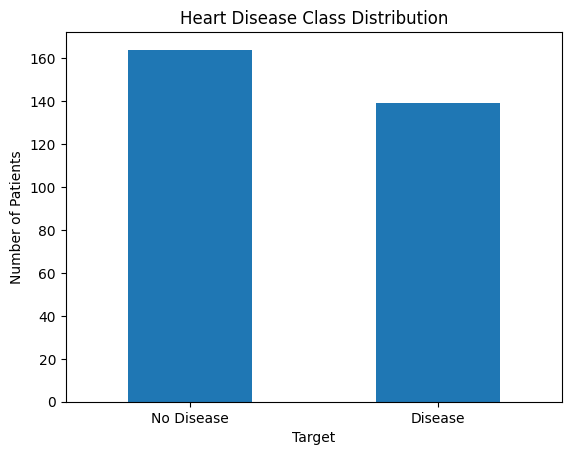

In [31]:
import matplotlib.pyplot as plt

y.value_counts().sort_index().plot(kind="bar")

plt.title("Heart Disease Class Distribution")
plt.xlabel("Target")
plt.ylabel("Number of Patients")
plt.xticks([0, 1], ["No Disease", "Disease"], rotation=0)
plt.show()

3.09 Check the cleaned dataset

In [32]:
print("Final dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df["target"].value_counts())

print("\nData types:")
print(df.dtypes)

Final dataset shape: (303, 14)

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Target distribution:
target
0    164
1    139
Name: count, dtype: int64

Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
target        int64
dtype: object


#Step 4 — Exploratory Data Analysis (EDA)

4.1 Import visualization libraries

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

4.2 Statistical summary

In [34]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


4.3 Numerical feature distributions

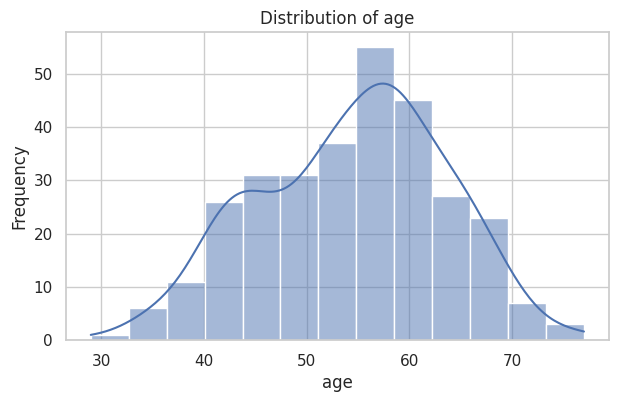

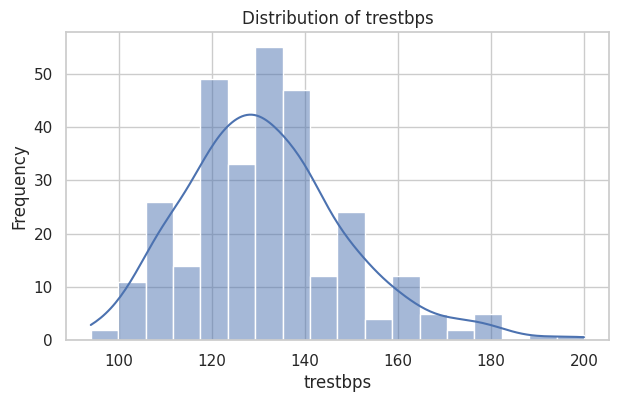

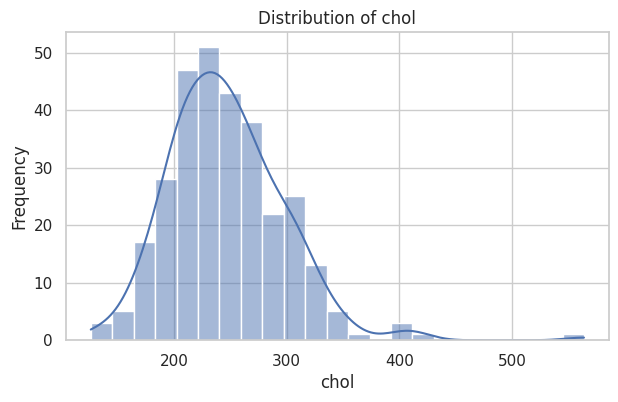

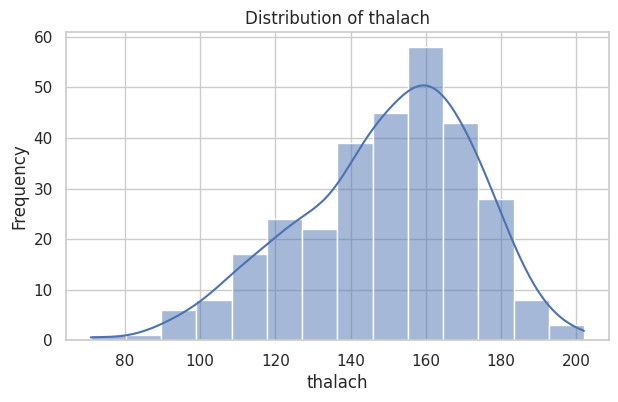

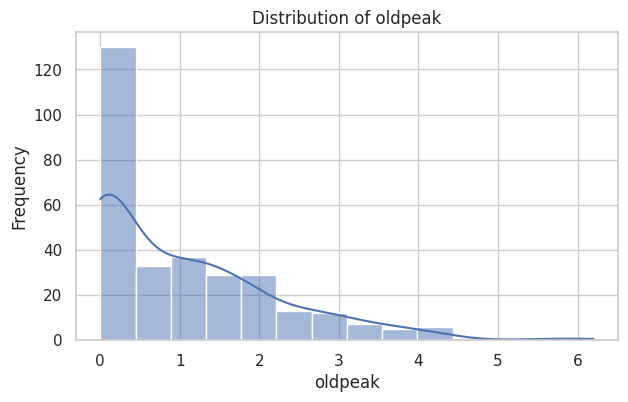

In [35]:
numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

for col in numerical_features:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

What we're looking for

For example:

Is age approximately normally distributed?
Are there extreme cholesterol values?
Is resting blood pressure heavily skewed?
How is maximum heart rate distributed?
Is oldpeak concentrated around particular values?

4.4 Compare numerical features by disease status

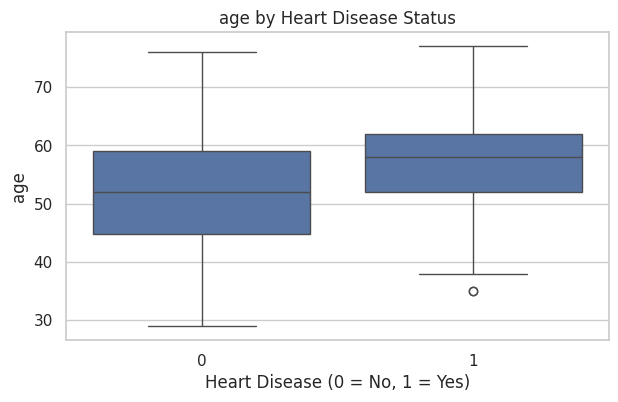

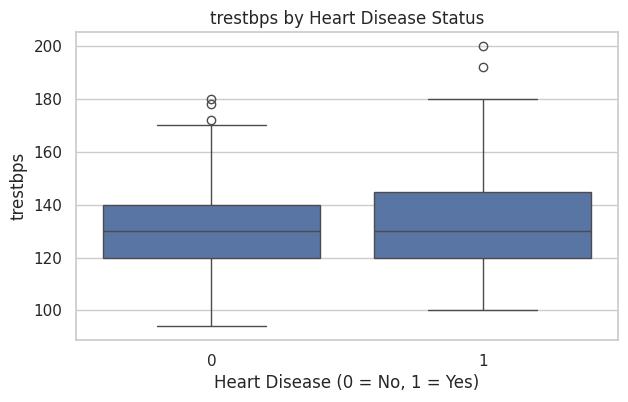

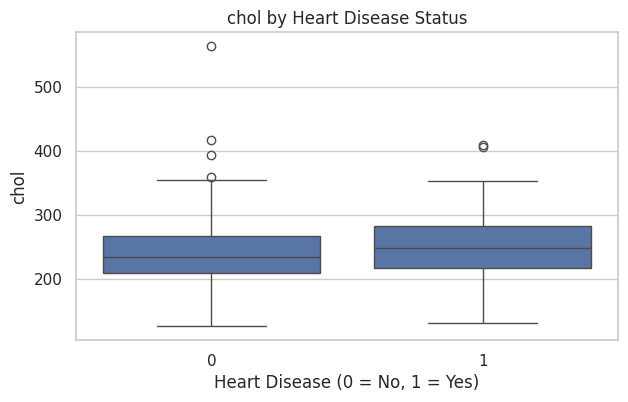

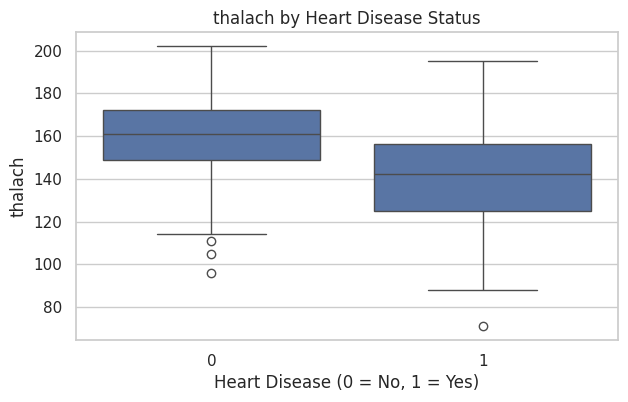

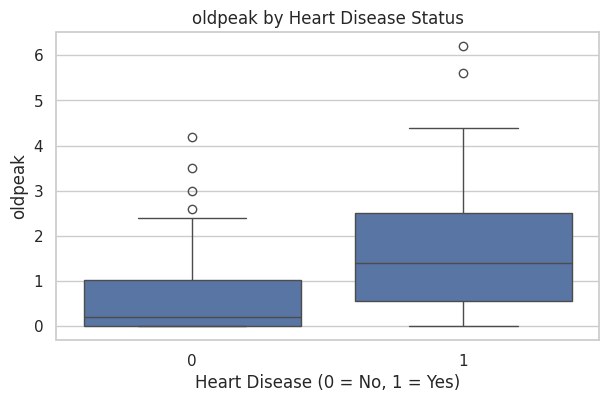

In [36]:
for col in numerical_features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x="target", y=col)
    plt.title(f"{col} by Heart Disease Status")
    plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
    plt.ylabel(col)
    plt.show()

4.5 Calculate group statistics

In [37]:
group_summary = df.groupby("target")[numerical_features].agg(
    ["mean", "median", "std"]
)

display(group_summary)

age                     trestbps                          chol  \
             mean median       std        mean median        std        mean   
target                                                                         
0       52.585366   52.0  9.511957  129.250000  130.0  16.204739  242.640244   
1       56.625899   58.0  7.938416  134.568345  130.0  18.769019  251.474820   

                             thalach                     oldpeak         \
       median        std        mean median        std      mean median   
target                                                                    
0       234.5  53.456580  158.378049  161.0  19.199080  0.586585    0.2   
1       249.0  49.486835  139.258993  142.0  22.593233  1.574101    1.4   

                  
             std  
target            
0       0.781734  
1       1.302580

4.6 Categorical feature analysis

In [38]:
categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

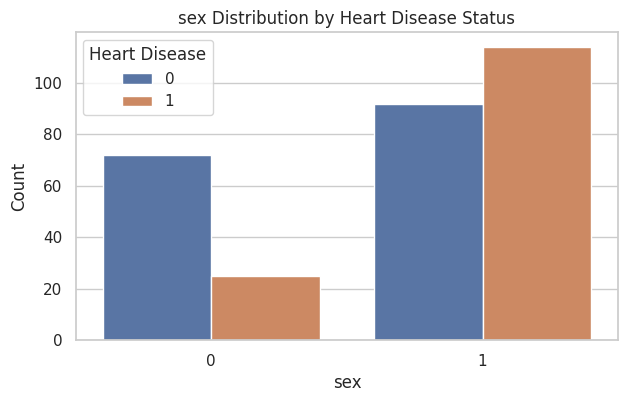

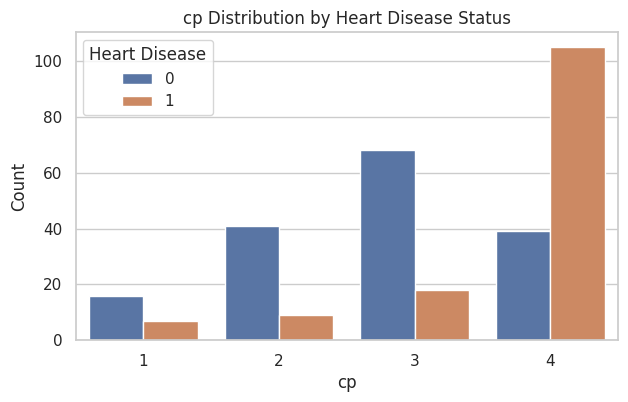

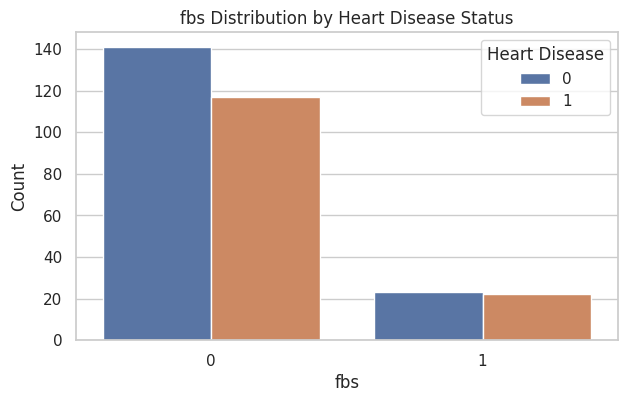

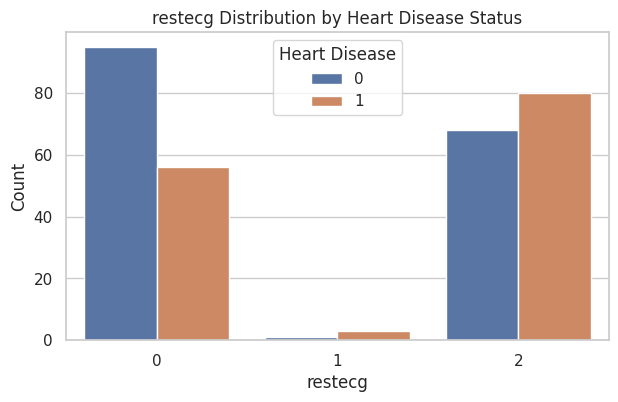

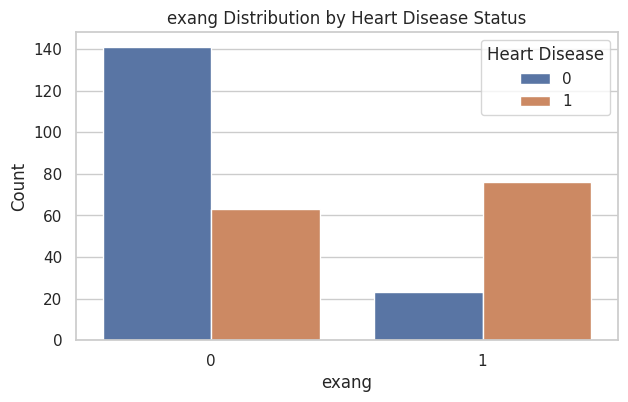

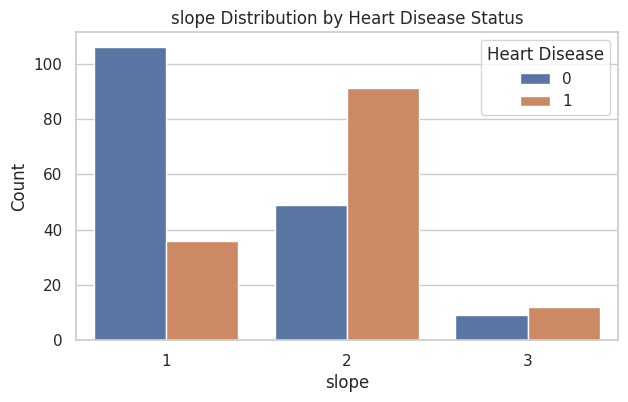

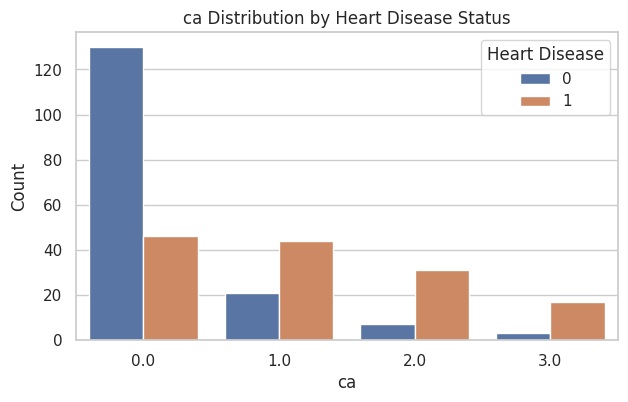

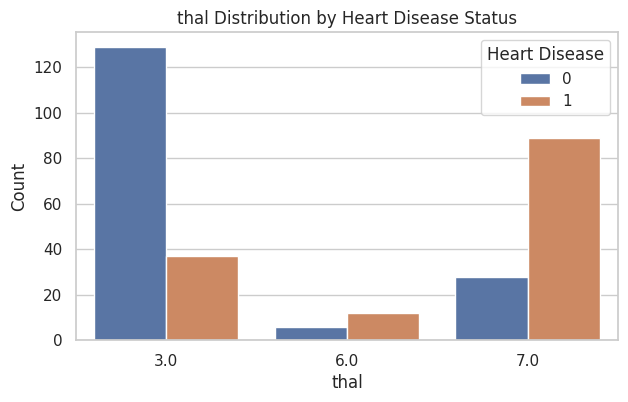

In [39]:
for col in categorical_features:
    plt.figure(figsize=(7, 4))
    sns.countplot(data=df, x=col, hue="target")
    plt.title(f"{col} Distribution by Heart Disease Status")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend(title="Heart Disease")
    plt.show()

4.7 Don't just look at counts — calculate disease rate

In [40]:
cp_risk = pd.crosstab(
    df["cp"],
    df["target"],
    normalize="index"
) * 100

display(cp_risk)

target,0,1
cp,,
1,69.565217,30.434783
2,82.000000,18.000000
3,79.069767,20.930233
4,27.083333,72.916667


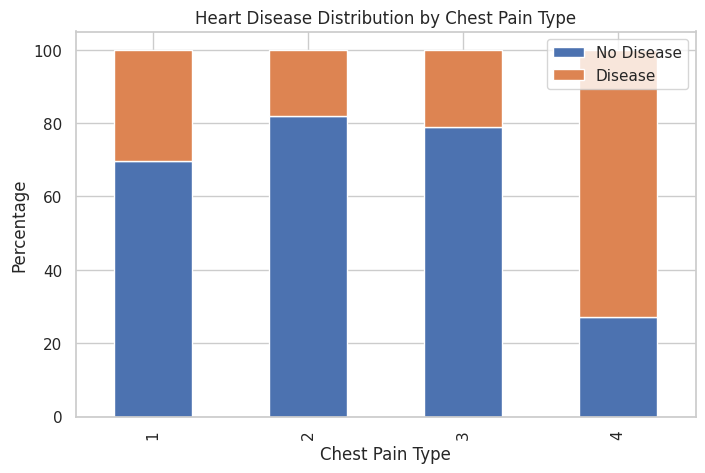

In [41]:
cp_risk.plot(kind="bar", stacked=True, figsize=(8, 5))

plt.title("Heart Disease Distribution by Chest Pain Type")
plt.xlabel("Chest Pain Type")
plt.ylabel("Percentage")
plt.legend(["No Disease", "Disease"])
plt.show()

4.8 Do this for all categorical variables

In [42]:
for col in categorical_features:
    risk_rate = df.groupby(col)["target"].mean() * 100

    print(f"\n{col}")
    display(risk_rate.round(2))


sex


,target
sex,
0,25.77
1,55.34



cp


,target
cp,
1,30.43
2,18.00
3,20.93
4,72.92



fbs


...

,target
slope,
1,25.35
2,65.00
3,57.14



ca


,target
ca,
0.0,26.14
1.0,67.69
2.0,81.58
3.0,85.00



thal


,target
thal,
3.0,22.29
6.0,66.67
7.0,76.07


4.9 Correlation analysis

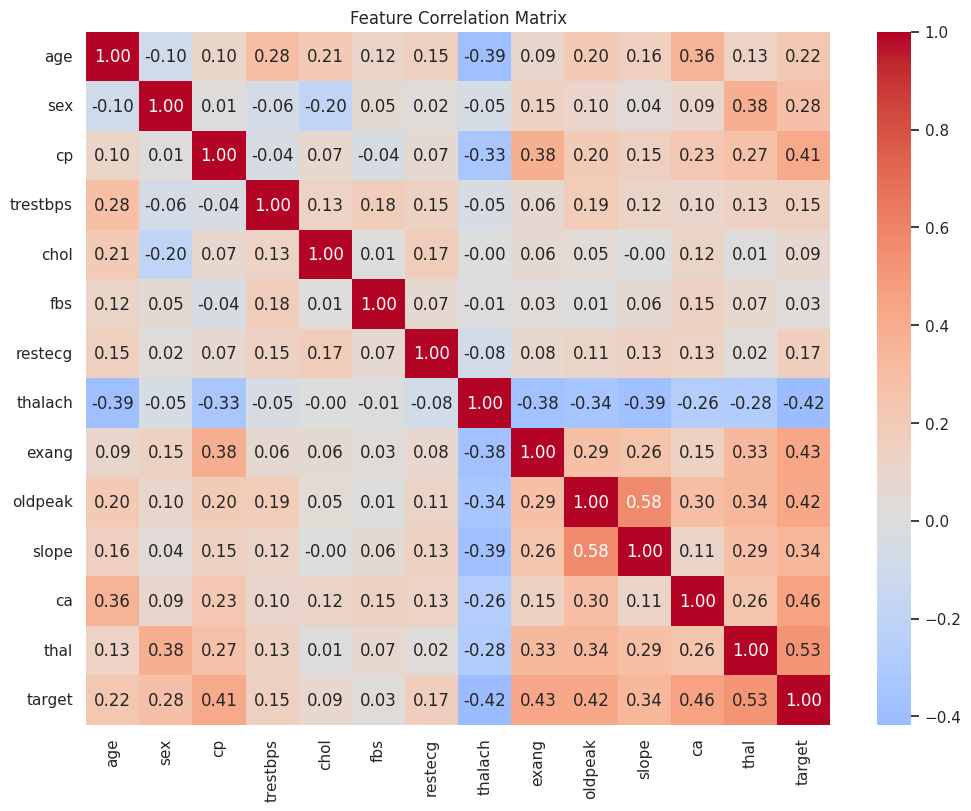

In [43]:
plt.figure(figsize=(12, 9))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.show()

4.10 Most important visualization: feature relationship with target

In [44]:
target_correlations = (
    df.corr(numeric_only=True)["target"]
    .drop("target")
    .sort_values()
)

display(target_correlations)

,target
thalach,-0.417167
fbs,0.025264
chol,0.085164
trestbps,0.150825
restecg,0.169202
age,0.223120
sex,0.276816
slope,0.339213
cp,0.414446
oldpeak,0.424510


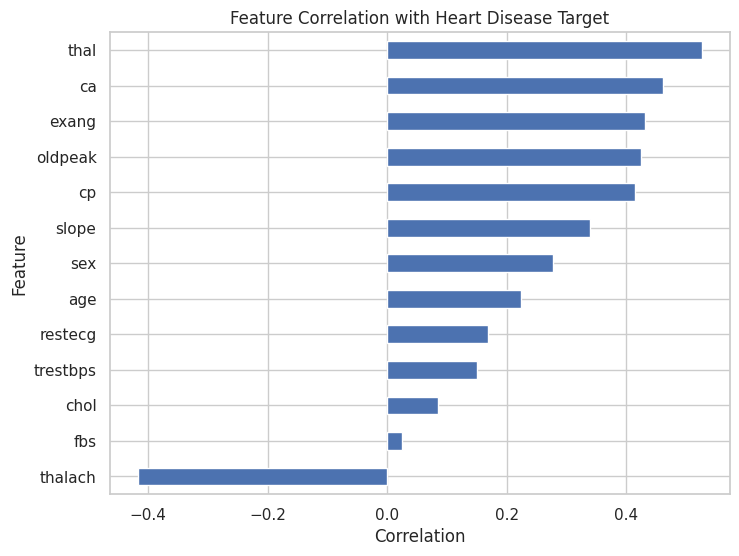

In [45]:
plt.figure(figsize=(8, 6))

target_correlations.plot(kind="barh")

plt.title("Feature Correlation with Heart Disease Target")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.show()

4.11 Check class balance

we all know
No disease = 164
Disease    = 139

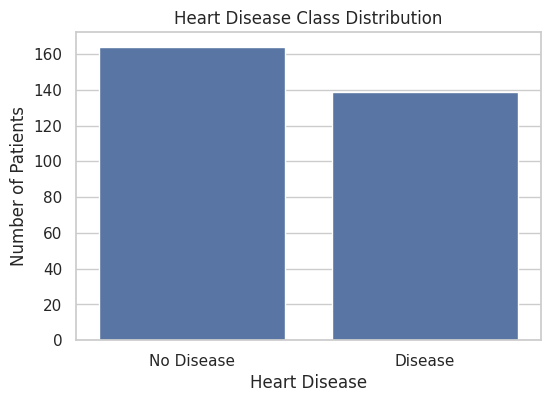

In [46]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="target")

plt.title("Heart Disease Class Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")
plt.xticks(
    [0, 1],
    ["No Disease", "Disease"]
)

plt.show()

4.12 Check potential outliers

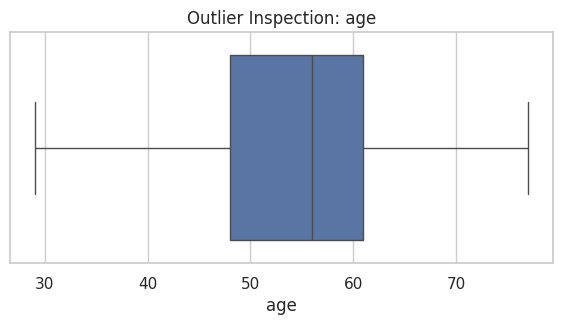

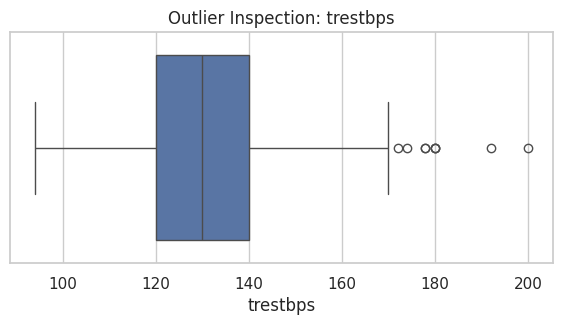

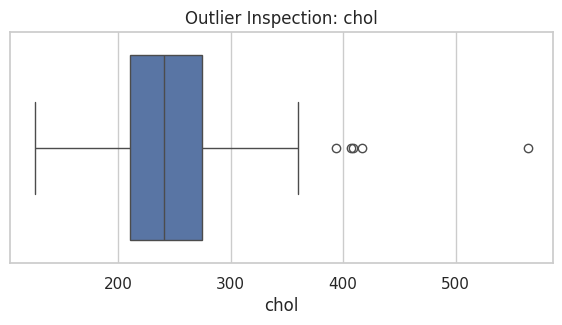

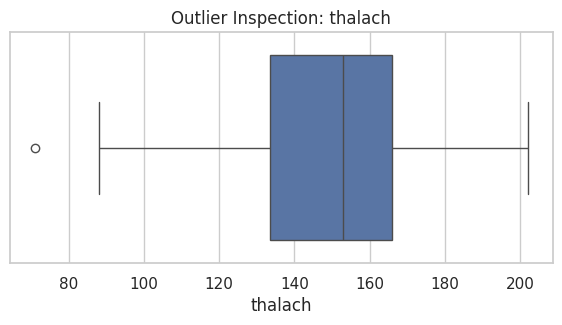

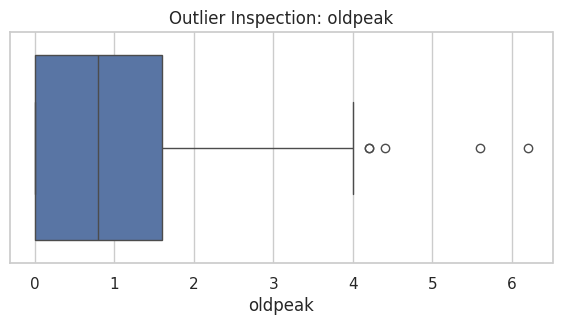

In [47]:
for col in numerical_features:
    plt.figure(figsize=(7, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Outlier Inspection: {col}")
    plt.show()

4.13 Create an EDA summary

### EDA Conclusions

The exploratory analysis identified several differences between patients with and without heart disease. The disease-positive group had a higher mean age (56.63 vs. 52.59 years), higher mean resting blood pressure (134.57 vs. 129.25), and higher mean cholesterol (251.47 vs. 242.64).

Maximum achieved heart rate (`thalach`) showed a notable difference between the groups, with a mean of 139.26 in the disease-positive group compared with 158.38 in the disease-negative group. Similarly, `oldpeak` was substantially higher among disease-positive observations (mean 1.57 vs. 0.59).

Correlation analysis showed that `thal`, `ca`, `exang`, `oldpeak`, and `cp` had the strongest positive associations with the binary target, while `thalach` showed a relatively strong negative association. In contrast, `fbs` and `chol` exhibited weak linear correlations with the target.

These findings are exploratory and do not establish causal relationships. Furthermore, correlation alone does not determine predictive importance. Therefore, multiple machine-learning models will be trained and compared to determine whether these variables contribute to predictive performance, including through potentially nonlinear relationships.


#Step 5 — Train/Test Split + Preprocessing

5.1 Define X and y

In [48]:
X = df.drop(columns=["target"])
y = df["target"]

In [49]:
print("X:", X.shape)
print("y:", y.shape)

X: (303, 13)
y: (303,)


5.2 Define feature types

In [50]:
numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

5.3 Train/test split

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (242, 13)
Test set: (61, 13)

Training target distribution:
target
0    0.541322
1    0.458678
Name: proportion, dtype: float64

Test target distribution:
target
0    0.540984
1    0.459016
Name: proportion, dtype: float64


5.4 Build preprocessing pipelines

In [52]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [53]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [54]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

5.5 Combine them

In [55]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

5.8 Check the missing values

In [56]:
print("Training missing values:")
print(X_train.isnull().sum())

print("\nTest missing values:")
print(X_test.isnull().sum())

Training missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          1
thal        1
dtype: int64

Test missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          3
thal        1
dtype: int64


#Step 6 — Build Our First ML Model: Logistic Regression

Can a relatively simple linear classification model predict heart-disease risk from these clinical features?

6.1 Import Logistic Regression

In [57]:
from sklearn.linear_model import LogisticRegression

6.2 Create the complete ML pipeline

In [58]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

6.3 Train the model

In [59]:
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'cp', 'fbs',
                                                   'restecg', 'exang', 'slope',
                                                   'ca', 'thal'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

6.4 Generate predictions

In [60]:
y_pred_lr = logistic_model.predict(X_test)

y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

6.5 Evaluate the model

In [61]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [62]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_roc_auc = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression Results")
print("-" * 35)
print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1 Score : {lr_f1:.4f}")
print(f"ROC-AUC  : {lr_roc_auc:.4f}")

Logistic Regression Results
-----------------------------------
Accuracy : 0.8852
Precision: 0.8387
Recall   : 0.9286
F1 Score : 0.8814
ROC-AUC  : 0.9665


6.6 Classification report

In [63]:
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["No Disease", "Disease"]
))

              precision    recall  f1-score   support

  No Disease       0.93      0.85      0.89        33
     Disease       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



6.7 Confusion matrix

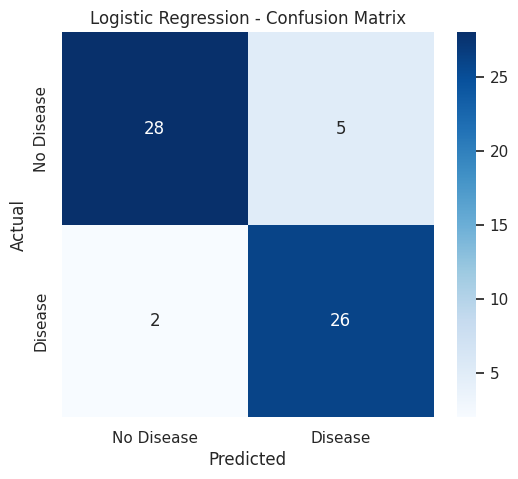

In [64]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

6.8 Create a results table

In [65]:
results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [lr_accuracy],
    "Precision": [lr_precision],
    "Recall": [lr_recall],
    "F1 Score": [lr_f1],
    "ROC-AUC": [lr_roc_auc]
})

display(results)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.885246,0.83871,0.928571,0.881356,0.96645


#Step 7 — Random Forest

7.1 Import Random Forest

In [66]:
from sklearn.ensemble import RandomForestClassifier

7.2 Build the pipeline

In [67]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

7.3 Train

In [68]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'cp', 'fbs',
                                                   'restecg', 'exang', 'slope',
                                                   'ca', 'thal'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, random_state=42))])

7.4 Predict

In [69]:
y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

7.5 Evaluate

In [70]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("-" * 35)
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

Random Forest Results
-----------------------------------
Accuracy : 0.8852
Precision: 0.8387
Recall   : 0.9286
F1 Score : 0.8814
ROC-AUC  : 0.9405


7.6 Classification report

In [71]:
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["No Disease", "Disease"]
))

              precision    recall  f1-score   support

  No Disease       0.93      0.85      0.89        33
     Disease       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



7.7 Confusion matrix

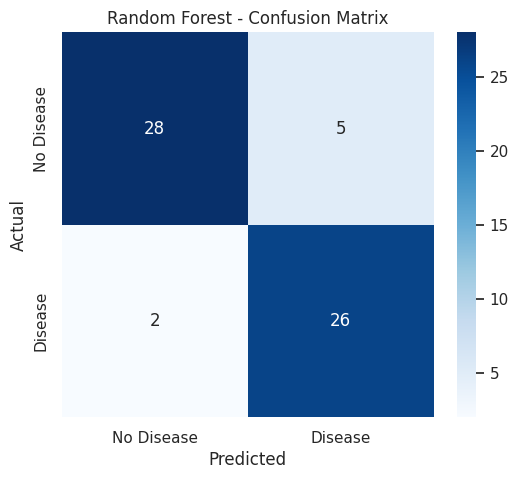

In [72]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

7.8 Compare it with Logistic Regression

In [73]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy
    ],
    "Precision": [
        lr_precision,
        rf_precision
    ],
    "Recall": [
        lr_recall,
        rf_recall
    ],
    "F1 Score": [
        lr_f1,
        rf_f1
    ],
    "ROC-AUC": [
        lr_roc_auc,
        rf_roc_auc
    ]
})

display(results.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8852,0.8387,0.9286,0.8814,0.9665
1,Random Forest,0.8852,0.8387,0.9286,0.8814,0.9405


#Step 8 — XGBoost

In [74]:
!pip install -q xgboost

In [75]:
from xgboost import XGBClassifier

8.1 Create the XGBoost pipeline

In [76]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            n_estimators=200,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42
        ))
    ]
)

8.2 Train

In [77]:
xgb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'cp', '...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

8.3 Predict

In [78]:
y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

8.4 Evaluate

In [79]:
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_roc_auc = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost Results")
print("-" * 35)
print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_roc_auc:.4f}")

XGBoost Results
-----------------------------------
Accuracy : 0.9180
Precision: 0.8710
Recall   : 0.9643
F1 Score : 0.9153
ROC-AUC  : 0.9481


8.5 Classification report

In [80]:
print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=["No Disease", "Disease"]
))

              precision    recall  f1-score   support

  No Disease       0.97      0.88      0.92        33
     Disease       0.87      0.96      0.92        28

    accuracy                           0.92        61
   macro avg       0.92      0.92      0.92        61
weighted avg       0.92      0.92      0.92        61



8.6 Confusion matrix

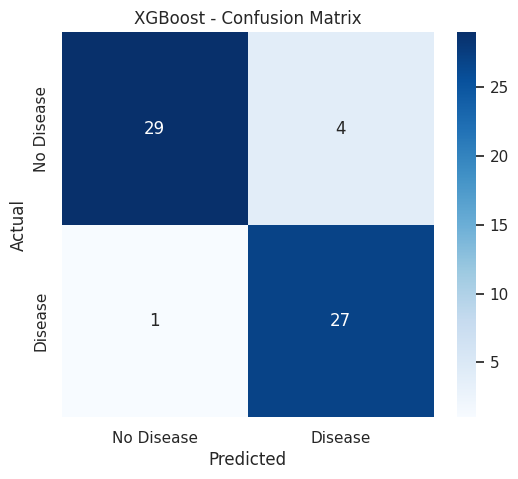

In [81]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

8.7 Update our comparison table

In [82]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        lr_precision,
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        lr_recall,
        rf_recall,
        xgb_recall
    ],
    "F1 Score": [
        lr_f1,
        rf_f1,
        xgb_f1
    ],
    "ROC-AUC": [
        lr_roc_auc,
        rf_roc_auc,
        xgb_roc_auc
    ]
})

display(results.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8852,0.8387,0.9286,0.8814,0.9665
1,Random Forest,0.8852,0.8387,0.9286,0.8814,0.9405
2,XGBoost,0.9180,0.8710,0.9643,0.9153,0.9481


#Step 9 — Cross-Validation

9.1 Import cross-validation tools

In [83]:
from sklearn.model_selection import StratifiedKFold, cross_validate

In [84]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

9.2 Define the metrics

In [85]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

9.3 Cross-validate Logistic Regression

In [86]:
lr_cv = cross_validate(
    logistic_model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [87]:
def summarize_cv(cv_results, model_name):
    return {
        "Model": model_name,
        "Accuracy Mean": cv_results["test_accuracy"].mean(),
        "Accuracy SD": cv_results["test_accuracy"].std(),
        "Precision Mean": cv_results["test_precision"].mean(),
        "Precision SD": cv_results["test_precision"].std(),
        "Recall Mean": cv_results["test_recall"].mean(),
        "Recall SD": cv_results["test_recall"].std(),
        "F1 Mean": cv_results["test_f1"].mean(),
        "F1 SD": cv_results["test_f1"].std(),
        "ROC-AUC Mean": cv_results["test_roc_auc"].mean(),
        "ROC-AUC SD": cv_results["test_roc_auc"].std()
    }

In [88]:
lr_cv_summary = summarize_cv(
    lr_cv,
    "Logistic Regression"
)

display(
    pd.DataFrame([lr_cv_summary]).round(4)
)

,Model,Accuracy Mean,Accuracy SD,Precision Mean,Precision SD,Recall Mean,Recall SD,F1 Mean,F1 SD,ROC-AUC Mean,ROC-AUC SD
0,Logistic Regression,0.8547,0.0485,0.8744,0.0572,0.7979,0.0727,0.8332,0.0579,0.9188,0.0207


9.4 Cross-validate Random Forest

In [89]:
rf_cv = cross_validate(
    rf_model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

rf_cv_summary = summarize_cv(
    rf_cv,
    "Random Forest"
)

display(
    pd.DataFrame([rf_cv_summary]).round(4)
)

,Model,Accuracy Mean,Accuracy SD,Precision Mean,Precision SD,Recall Mean,Recall SD,F1 Mean,F1 SD,ROC-AUC Mean,ROC-AUC SD
0,Random Forest,0.8417,0.0215,0.856,0.0459,0.7915,0.0254,0.8214,0.0198,0.9156,0.0208


9.5 Cross-validate XGBoost

In [90]:
xgb_cv = cross_validate(
    xgb_model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

xgb_cv_summary = summarize_cv(
    xgb_cv,
    "XGBoost"
)

display(
    pd.DataFrame([xgb_cv_summary]).round(4)
)

,Model,Accuracy Mean,Accuracy SD,Precision Mean,Precision SD,Recall Mean,Recall SD,F1 Mean,F1 SD,ROC-AUC Mean,ROC-AUC SD
0,XGBoost,0.8252,0.026,0.8368,0.0582,0.7767,0.0367,0.8035,0.0233,0.9,0.0144


9.6 Create the research comparison table

In [91]:
cv_results_df = pd.DataFrame([
    lr_cv_summary,
    rf_cv_summary,
    xgb_cv_summary
])

display(
    cv_results_df.round(4)
)

,Model,Accuracy Mean,Accuracy SD,Precision Mean,Precision SD,Recall Mean,Recall SD,F1 Mean,F1 SD,ROC-AUC Mean,ROC-AUC SD
0,Logistic Regression,0.8547,0.0485,0.8744,0.0572,0.7979,0.0727,0.8332,0.0579,0.9188,0.0207
1,Random Forest,0.8417,0.0215,0.8560,0.0459,0.7915,0.0254,0.8214,0.0198,0.9156,0.0208
2,XGBoost,0.8252,0.0260,0.8368,0.0582,0.7767,0.0367,0.8035,0.0233,0.9000,0.0144


"Using stratified five-fold cross-validation, the proposed models were evaluated across multiple performance metrics, including accuracy, precision, recall, F1-score, and ROC-AUC. Mean performance and variability across folds were considered when selecting the final model."

"Although XGBoost achieved higher performance on the initial held-out test split, five-fold stratified cross-validation showed that Logistic Regression achieved the strongest average performance across accuracy, precision, recall, F1-score, and ROC-AUC. This suggests that the increased complexity of tree-based models did not necessarily translate into better generalization on this relatively small dataset."



#Step 10 — Hyperparameter Tuning

In [92]:
from sklearn.model_selection import RandomizedSearchCV

10.1 Create the parameter search space

In [93]:
xgb_param_grid = {
    "classifier__n_estimators": [100, 200, 300, 500],
    "classifier__max_depth": [2, 3, 4, 5],
    "classifier__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "classifier__subsample": [0.7, 0.8, 0.9, 1.0],
    "classifier__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "classifier__min_child_weight": [1, 3, 5],
    "classifier__gamma": [0, 0.1, 0.3, 0.5]
}

10.2 Randomized search

In [94]:
xgb_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_param_grid,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [95]:
xgb_search.fit(X, y)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['age',
                                                                                'trestbps',
                                                                                'chol',
                                                                                'thalach',
                                                                                'oldpeak']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(stra...
                   param_distributions={'classifier__colsample_bytree': [0.7,
                                                                         0.8,
                                                                         0.9,
                                                                         1.0],
                                        'classifier__gamma': [0, 0.1, 0.3, 0.5],
                                        'classifier__learning_rate': [0.01,
                                                                      0.03,
                                                                      0.05,
                                                                      0.1],
                                        'classifier__max_depth': [2, 3, 4, 5],
                                        'classifier__min_child_weight': [1, 3,
                                                                         5],
                                        'classifier__n_estimators': [100, 200,
                                                                     300, 500],
                                        'classifier__subsample': [0.7, 0.8, 0.9,
                                                                  1.0]},
                   random_state=42, scoring='roc_auc', verbose=1)

10.3 See the best parameters

In [96]:
print("Best Parameters:")
print(xgb_search.best_params_)

print("\nBest CV ROC-AUC:")
print(round(xgb_search.best_score_, 4))

Best Parameters:
{'classifier__subsample': 0.7, 'classifier__n_estimators': 500, 'classifier__min_child_weight': 5, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.01, 'classifier__gamma': 0.1, 'classifier__colsample_bytree': 0.7}

Best CV ROC-AUC:
0.9151


Step 10.4 Also tune Logistic Regression

In [97]:
lr_param_grid = {
    "classifier__C": [
        0.001,
        0.01,
        0.1,
        1,
        10,
        100
    ],
    "classifier__class_weight": [
        None,
        "balanced"
    ]
}

In [98]:
lr_search = RandomizedSearchCV(
    estimator=logistic_model,
    param_distributions=lr_param_grid,
    n_iter=12,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

In [99]:
lr_search.fit(X, y)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['age',
                                                                                'trestbps',
                                                                                'chol',
                                                                                'thalach',
                                                                                'oldpeak']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(stra...nt')),
                                                                                               ('encoder',
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               ['sex',
                                                                                'cp',
                                                                                'fbs',
                                                                                'restecg',
                                                                                'exang',
                                                                                'slope',
                                                                                'ca',
                                                                                'thal'])])),
                                             ('classifier',
                                              LogisticRegression(max_iter=1000,
                                                                 random_state=42))]),
                   n_iter=12, n_jobs=-1,
                   param_distributions={'classifier__C': [0.001, 0.01, 0.1, 1,
                                                          10, 100],
                                        'classifier__class_weight': [None,
                                                                     'balanced']},
                   random_state=42, scoring='roc_auc')

In [100]:
print("Best Logistic Regression Parameters:")
print(lr_search.best_params_)

print("\nBest CV ROC-AUC:")
print(round(lr_search.best_score_, 4))

Best Logistic Regression Parameters:
{'classifier__class_weight': None, 'classifier__C': 0.1}

Best CV ROC-AUC:
0.921


Possible outcomes

A. Logistic Regression remains best

Excellent. We have evidence that the simpler model generalizes better.

B. XGBoost becomes best

Also excellent. Then we have evidence that nonlinear modeling provides additional predictive value after optimization.

C. Models become very close

That's also interesting. We can then use additional considerations such as interpretability, calibration, recall, and SHAP to select the final model.

#Step 11 — Final Model Evaluation

11.1 Get the best models

In [101]:
best_lr = lr_search.best_estimator_
best_xgb = xgb_search.best_estimator_

11.2 Predict with tuned Logistic Regression

In [102]:
y_pred_lr_tuned = best_lr.predict(X_test)
y_prob_lr_tuned = best_lr.predict_proba(X_test)[:, 1]

In [103]:
lr_tuned_accuracy = accuracy_score(y_test, y_pred_lr_tuned)
lr_tuned_precision = precision_score(y_test, y_pred_lr_tuned)
lr_tuned_recall = recall_score(y_test, y_pred_lr_tuned)
lr_tuned_f1 = f1_score(y_test, y_pred_lr_tuned)
lr_tuned_auc = roc_auc_score(y_test, y_prob_lr_tuned)

print("Tuned Logistic Regression")
print("-" * 40)
print(f"Accuracy : {lr_tuned_accuracy:.4f}")
print(f"Precision: {lr_tuned_precision:.4f}")
print(f"Recall   : {lr_tuned_recall:.4f}")
print(f"F1 Score : {lr_tuned_f1:.4f}")
print(f"ROC-AUC  : {lr_tuned_auc:.4f}")

Tuned Logistic Regression
----------------------------------------
Accuracy : 0.9016
Precision: 0.8667
Recall   : 0.9286
F1 Score : 0.8966
ROC-AUC  : 0.9751


11.3 Predict with tuned XGBoost

In [104]:
y_pred_xgb_tuned = best_xgb.predict(X_test)
y_prob_xgb_tuned = best_xgb.predict_proba(X_test)[:, 1]

In [105]:
xgb_tuned_accuracy = accuracy_score(y_test, y_pred_xgb_tuned)
xgb_tuned_precision = precision_score(y_test, y_pred_xgb_tuned)
xgb_tuned_recall = recall_score(y_test, y_pred_xgb_tuned)
xgb_tuned_f1 = f1_score(y_test, y_pred_xgb_tuned)
xgb_tuned_auc = roc_auc_score(y_test, y_prob_xgb_tuned)

print("Tuned XGBoost")
print("-" * 40)
print(f"Accuracy : {xgb_tuned_accuracy:.4f}")
print(f"Precision: {xgb_tuned_precision:.4f}")
print(f"Recall   : {xgb_tuned_recall:.4f}")
print(f"F1 Score : {xgb_tuned_f1:.4f}")
print(f"ROC-AUC  : {xgb_tuned_auc:.4f}")

Tuned XGBoost
----------------------------------------
Accuracy : 0.9344
Precision: 0.9000
Recall   : 0.9643
F1 Score : 0.9310
ROC-AUC  : 0.9838


11.4 Final comparison

In [106]:
final_results = pd.DataFrame({
    "Model": [
        "Tuned Logistic Regression",
        "Tuned XGBoost"
    ],
    "Accuracy": [
        lr_tuned_accuracy,
        xgb_tuned_accuracy
    ],
    "Precision": [
        lr_tuned_precision,
        xgb_tuned_precision
    ],
    "Recall": [
        lr_tuned_recall,
        xgb_tuned_recall
    ],
    "F1 Score": [
        lr_tuned_f1,
        xgb_tuned_f1
    ],
    "ROC-AUC": [
        lr_tuned_auc,
        xgb_tuned_auc
    ]
})

display(final_results.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Tuned Logistic Regression,0.9016,0.8667,0.9286,0.8966,0.9751
1,Tuned XGBoost,0.9344,0.9000,0.9643,0.9310,0.9838


11.5 Confusion matrices

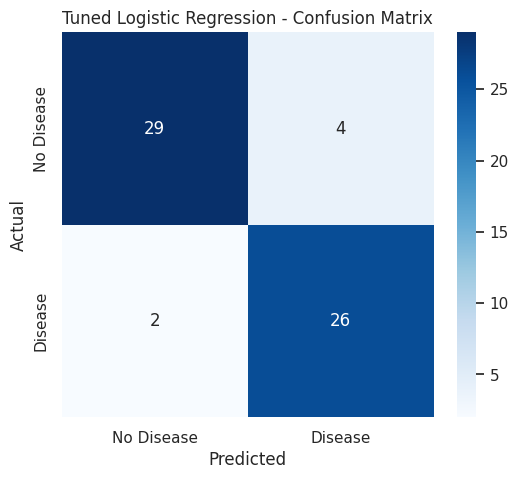

In [107]:
cm_lr_tuned = confusion_matrix(
    y_test,
    y_pred_lr_tuned
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr_tuned,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.title("Tuned Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

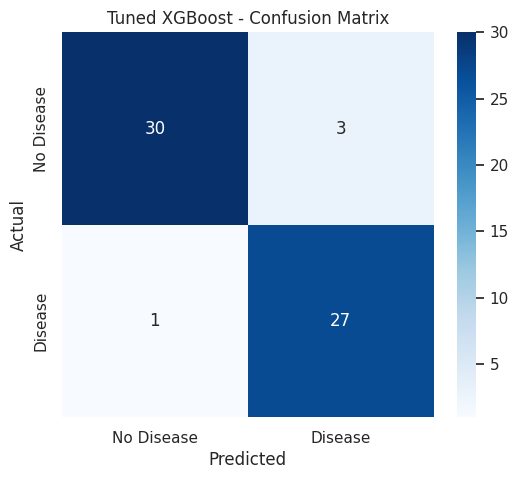

In [108]:
cm_xgb_tuned = confusion_matrix(
    y_test,
    y_pred_xgb_tuned
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_xgb_tuned,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.title("Tuned XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#Step 12 — Explainability with SHAP

Why did the XGBoost model make a particular prediction?
Patient
   ↓
XGBoost
   ↓
Predicted probability = 87%
   ↓
WHY?
   ├── ↑ oldpeak
   ├── ↑ ca
   ├── exercise-induced angina
   ├── ↓ thalach
   └── particular thal category

12.1 Install SHAP

In [109]:
!pip install -q shap

In [110]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

12.2 Extract the preprocessing and XGBoost model

In [111]:
best_preprocessor = best_xgb.named_steps["preprocessor"]
best_classifier = best_xgb.named_steps["classifier"]

In [112]:
X_test_transformed = best_preprocessor.transform(X_test)

In [113]:
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

12.3 Get the transformed feature names

In [114]:
feature_names = best_preprocessor.get_feature_names_out()

print("Number of transformed features:", len(feature_names))
print(feature_names)

Number of transformed features: 28
['num__age' 'num__trestbps' 'num__chol' 'num__thalach' 'num__oldpeak'
 'cat__sex_0.0' 'cat__sex_1.0' 'cat__cp_1.0' 'cat__cp_2.0' 'cat__cp_3.0'
 'cat__cp_4.0' 'cat__fbs_0.0' 'cat__fbs_1.0' 'cat__restecg_0.0'
 'cat__restecg_1.0' 'cat__restecg_2.0' 'cat__exang_0.0' 'cat__exang_1.0'
 'cat__slope_1.0' 'cat__slope_2.0' 'cat__slope_3.0' 'cat__ca_0.0'
 'cat__ca_1.0' 'cat__ca_2.0' 'cat__ca_3.0' 'cat__thal_3.0' 'cat__thal_6.0'
 'cat__thal_7.0']


12.4 Create the SHAP explainer

In [115]:
explainer = shap.TreeExplainer(best_classifier)

In [116]:
shap_values = explainer.shap_values(X_test_transformed)

12.5 Global feature importance

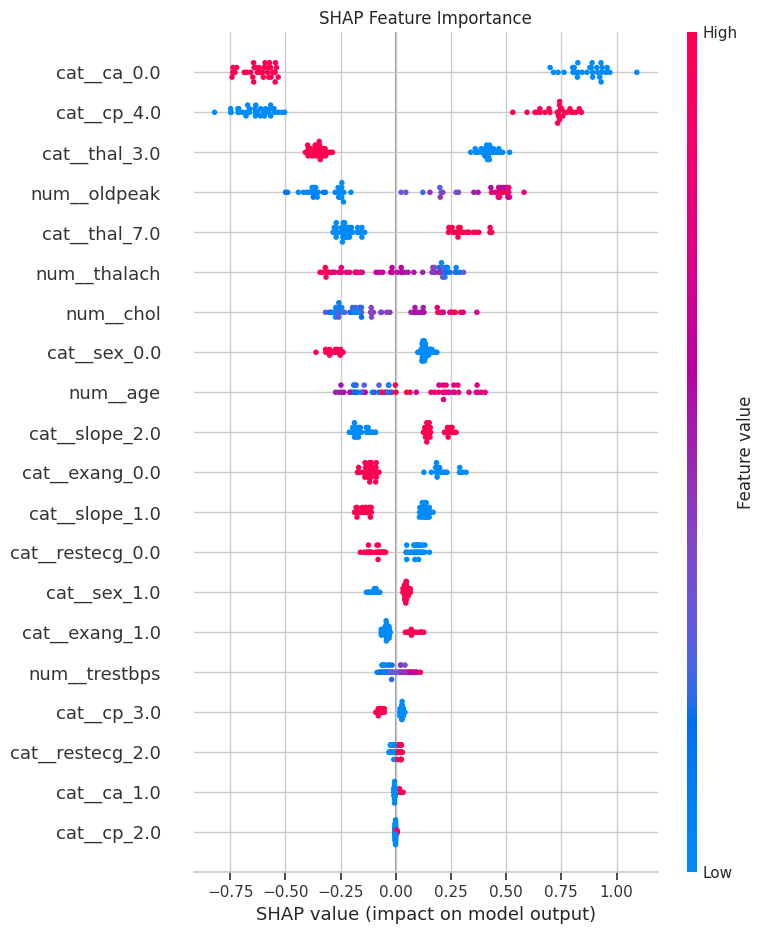

In [117]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    show=False
)

plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.show()

12.6 SHAP bar plot

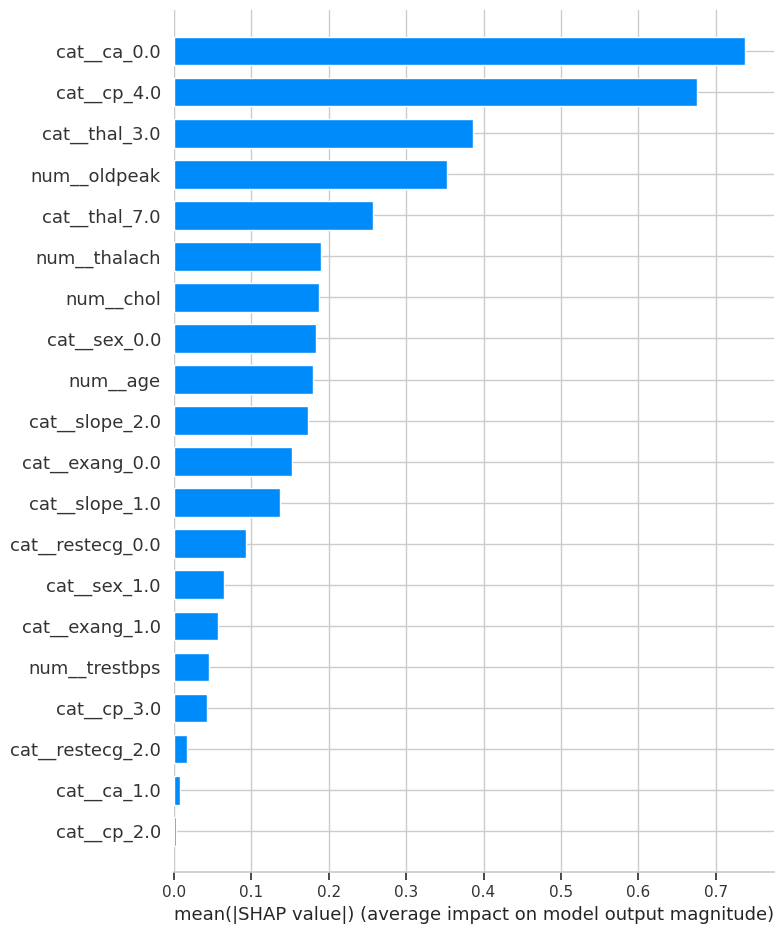

In [118]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

12.7 Individual patient explanation

In [119]:
patient_index = 0

patient_data = X_test_transformed[patient_index:patient_index+1]

In [120]:
patient_shap = explainer.shap_values(patient_data)

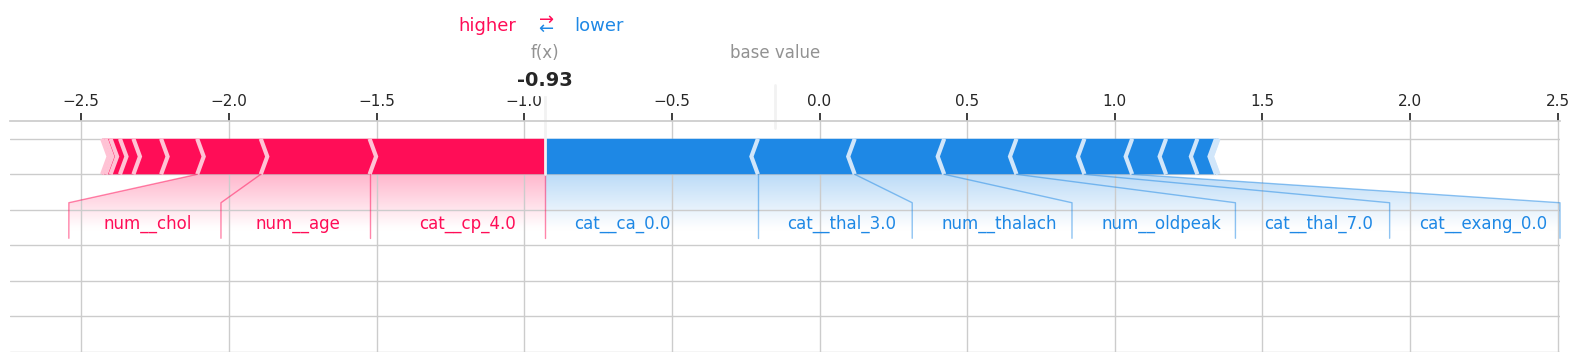

In [121]:
shap.force_plot(
    explainer.expected_value,
    patient_shap[0],
    feature_names=feature_names,
    matplotlib=True
)

plt.show()

Step 12A — Aggregate SHAP by original feature

In [122]:
# Calculate mean absolute SHAP values
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)

shap_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": mean_abs_shap
})

# Remove preprocessing prefixes
shap_importance["original_feature"] = (
    shap_importance["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.replace(r"_\d+\.0$", "", regex=True)
)

# Aggregate one-hot encoded features
grouped_shap = (
    shap_importance
    .groupby("original_feature")["mean_abs_shap"]
    .sum()
    .sort_values(ascending=False)
)

display(grouped_shap)

,mean_abs_shap
original_feature,
ca,0.746068
cp,0.721297
thal,0.643999
oldpeak,0.352221
slope,0.310834
sex,0.248461
exang,0.208157
thalach,0.190547
chol,0.186965


Step 12B — Plot original clinical features

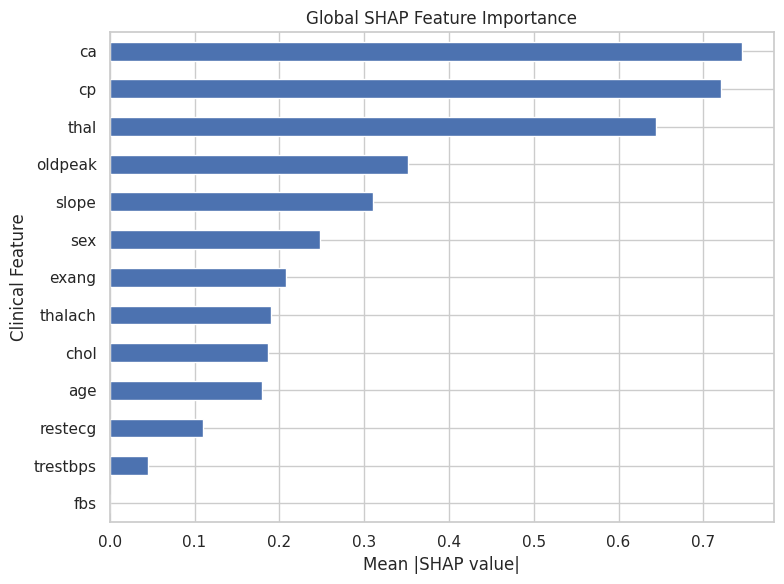

In [123]:
plt.figure(figsize=(8, 6))

grouped_shap.sort_values().plot(kind="barh")

plt.xlabel("Mean |SHAP value|")
plt.ylabel("Clinical Feature")
plt.title("Global SHAP Feature Importance")
plt.tight_layout()

plt.show()

Step 12C — Now we need direction, not just importance
Which values push predictions toward higher or lower disease probability?

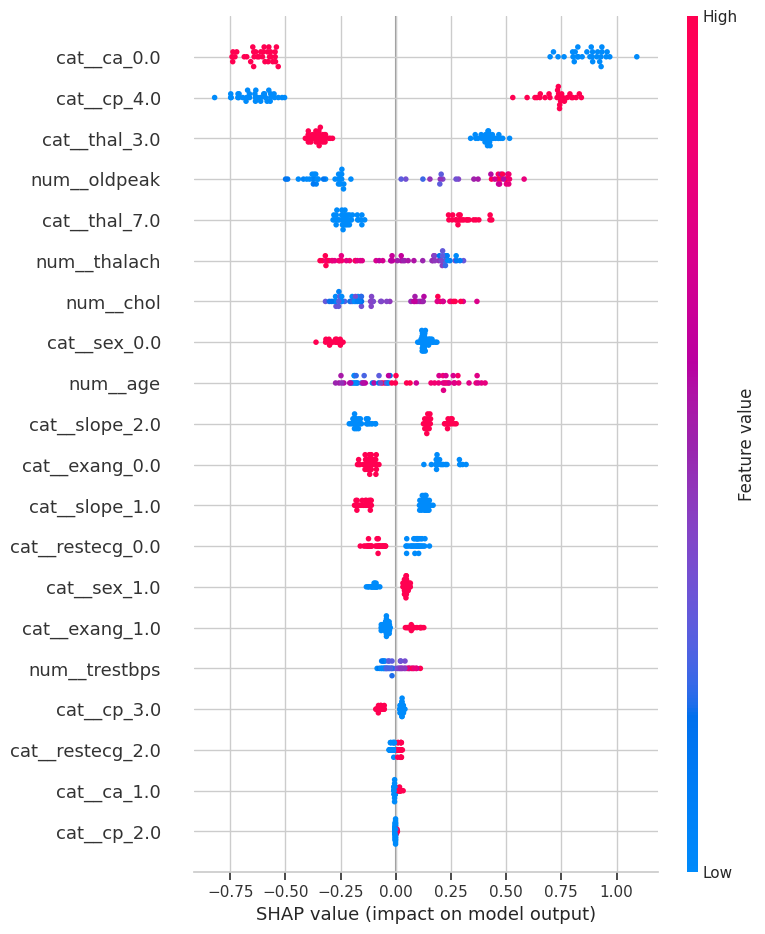

In [124]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

Step 12D — Individual patient explanation ⭐

In [125]:
patient_index = 0

patient_shap_values = shap_values[patient_index]

patient_df = pd.DataFrame({
    "Feature": feature_names,
    "SHAP": patient_shap_values
})

patient_df["Absolute_SHAP"] = patient_df["SHAP"].abs()

patient_df = patient_df.sort_values(
    "Absolute_SHAP",
    ascending=False
)

display(patient_df.head(10))

,Feature,SHAP,Absolute_SHAP
21,cat__ca_0.0,-0.720290,0.720290
10,cat__cp_4.0,0.594804,0.594804
0,num__age,0.368435,0.368435
25,cat__thal_3.0,-0.327862,0.327862
3,num__thalach,-0.303094,0.303094
4,num__oldpeak,-0.244823,0.244823
27,cat__thal_7.0,-0.230078,0.230078
2,num__chol,0.215315,0.215315
16,cat__exang_0.0,-0.161647,0.161647
5,cat__sex_0.0,0.122255,0.122255


Step 12E — Visualize that patient's explanation

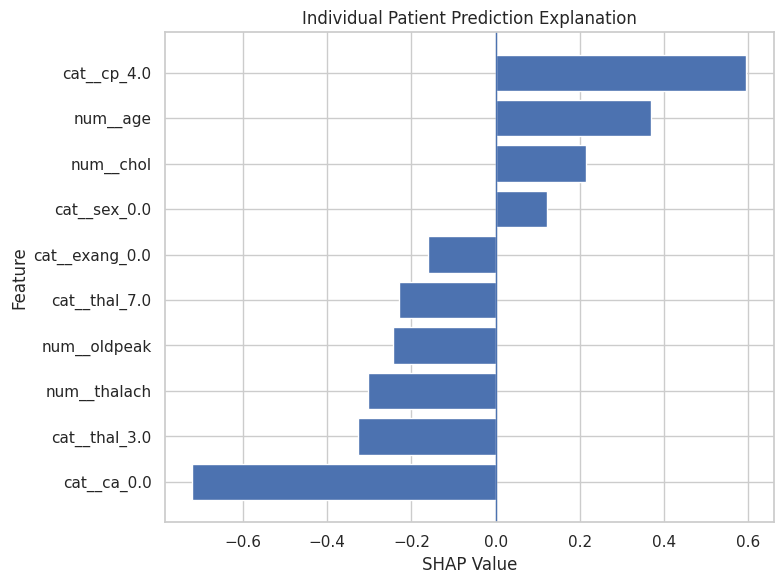

In [126]:
top_patient = patient_df.head(10).sort_values("SHAP")

plt.figure(figsize=(8, 6))

plt.barh(
    top_patient["Feature"],
    top_patient["SHAP"]
)

plt.axvline(0, linewidth=1)

plt.xlabel("SHAP Value")
plt.ylabel("Feature")
plt.title("Individual Patient Prediction Explanation")

plt.tight_layout()
plt.show()

#Step 13 — Error Analysis

In [127]:
error_analysis = X_test.copy()

error_analysis["Actual"] = y_test.values
error_analysis["Predicted"] = y_pred_xgb_tuned
error_analysis["Probability"] = y_prob_xgb_tuned

error_analysis["Correct"] = (
    error_analysis["Actual"] ==
    error_analysis["Predicted"]
)

display(
    error_analysis[error_analysis["Correct"] == False]
)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,Actual,Predicted,Probability,Correct
271,66,1,4,160,228,0,2,138,0,2.3,1,0.0,6.0,0,1,0.544091,False
196,69,1,1,160,234,1,2,131,0,0.1,2,1.0,3.0,0,1,0.590676,False
66,60,1,3,140,185,0,2,155,0,3.0,2,0.0,3.0,1,0,0.341556,False
92,62,1,3,130,231,0,0,146,0,1.8,2,3.0,7.0,0,1,0.798367,False


false negatives

In [128]:
false_negatives = error_analysis[
    (error_analysis["Actual"] == 1) &
    (error_analysis["Predicted"] == 0)
]

display(false_negatives)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,Actual,Predicted,Probability,Correct
66,60,1,3,140,185,0,2,155,0,3.0,2,0.0,3.0,1,0,0.341556,False


false positives

In [129]:
false_positives = error_analysis[
    (error_analysis["Actual"] == 0) &
    (error_analysis["Predicted"] == 1)
]

display(false_positives)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,Actual,Predicted,Probability,Correct
271,66,1,4,160,228,0,2,138,0,2.3,1,0.0,6.0,0,1,0.544091,False
196,69,1,1,160,234,1,2,131,0,0.1,2,1.0,3.0,0,1,0.590676,False
92,62,1,3,130,231,0,0,146,0,1.8,2,3.0,7.0,0,1,0.798367,False


Step 13A — Analyze the false negative

In [130]:
display(
    false_negatives[
        ["Actual", "Predicted", "Probability"]
    ]
)

,Actual,Predicted,Probability
66,1,0,0.341556


False Negative
34.16% → missed positive

False Positive
54.41% → borderline

False Positive
59.07% → borderline

False Positive
79.84% → confidently wrong

SHAP Reasearch Conclusion : "SHAP analysis indicated that CA, chest-pain category (CP), and Thal were the most influential features in the XGBoost model, followed by Oldpeak and Slope. The beeswarm analysis further demonstrated that different feature values produced both positive and negative contributions to the model output, providing patient-level and feature-level interpretability beyond conventional feature importance measures."

Step 13A — Explain the False Negative

In [131]:
fn_index = false_negatives.index[0]

fn_position = X_test.index.get_loc(fn_index)

print("Original index:", fn_index)
print("Test position:", fn_position)

Original index: 66
Test position: 37


In [132]:
fn_shap = shap_values[fn_position]

fn_explanation = pd.DataFrame({
    "Feature": feature_names,
    "SHAP": fn_shap
})

fn_explanation["Absolute_SHAP"] = fn_explanation["SHAP"].abs()

fn_explanation = fn_explanation.sort_values(
    "Absolute_SHAP",
    ascending=False
)

display(fn_explanation.head(10))

,Feature,SHAP,Absolute_SHAP
21,cat__ca_0.0,-0.657002,0.657002
4,num__oldpeak,0.512086,0.512086
10,cat__cp_4.0,-0.503507,0.503507
0,num__age,0.404659,0.404659
25,cat__thal_3.0,-0.286467,0.286467
2,num__chol,-0.257712,0.257712
19,cat__slope_2.0,0.249328,0.249328
27,cat__thal_7.0,-0.226265,0.226265
5,cat__sex_0.0,0.164126,0.164126
16,cat__exang_0.0,-0.115085,0.115085


False negative : "The false-negative case demonstrated competing feature contributions. Although age, oldpeak and slope contributed toward a positive prediction, strong negative contributions from encoded CA, CP and Thal categories shifted the model toward the negative class. This illustrates how the model integrates multiple clinical variables rather than relying on a single predictor."

Step 13B — Explain the confident False Positive

In [133]:
fp_confident_index = false_positives["Probability"].idxmax()

fp_position = X_test.index.get_loc(fp_confident_index)

print("Original index:", fp_confident_index)
print("Test position:", fp_position)

Original index: 92
Test position: 40


In [134]:
fp_shap = shap_values[fp_position]

fp_explanation = pd.DataFrame({
    "Feature": feature_names,
    "SHAP": fp_shap
})

fp_explanation["Absolute_SHAP"] = fp_explanation["SHAP"].abs()

fp_explanation = fp_explanation.sort_values(
    "Absolute_SHAP",
    ascending=False
)

display(fp_explanation.head(10))

,Feature,SHAP,Absolute_SHAP
21,cat__ca_0.0,0.801037,0.801037
10,cat__cp_4.0,-0.662248,0.662248
25,cat__thal_3.0,0.389393,0.389393
4,num__oldpeak,0.353745,0.353745
19,cat__slope_2.0,0.265676,0.265676
27,cat__thal_7.0,0.255671,0.255671
0,num__age,0.159772,0.159772
18,cat__slope_1.0,0.150368,0.150368
5,cat__sex_0.0,0.148572,0.148572
13,cat__restecg_0.0,-0.119731,0.119731


False-positive: "The confidently misclassified false-positive case received strong positive contributions from CA, Thal, Oldpeak and Slope. Despite a substantial negative contribution from the CP category, the combined positive contributions resulted in a predicted disease probability of 79.84%. This demonstrates a limitation of the model: strong learned associations can occasionally produce confident predictions that disagree with the observed target."

#Step 14 — Probability calibration

Step 14A — Calibration curve

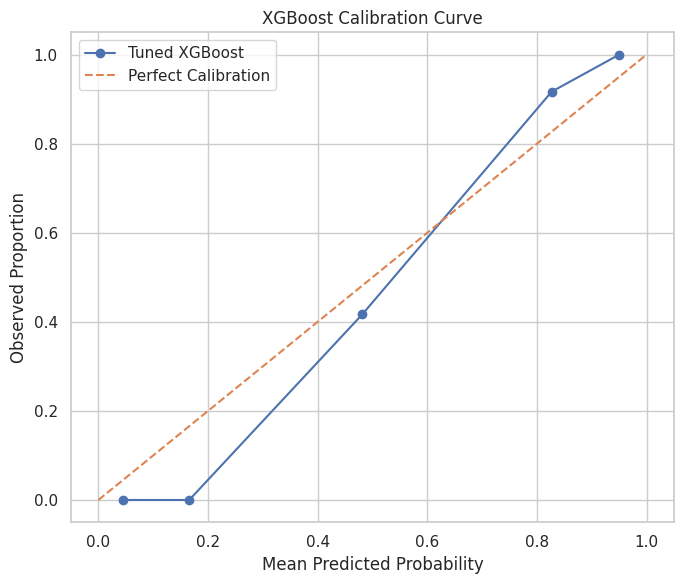

In [135]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

prob_true, prob_pred = calibration_curve(
    y_test,
    y_prob_xgb_tuned,
    n_bins=5,
    strategy="quantile"
)

plt.figure(figsize=(7, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Tuned XGBoost"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Proportion")
plt.title("XGBoost Calibration Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [136]:
brier = brier_score_loss(
    y_test,
    y_prob_xgb_tuned
)

print("Brier Score:", round(brier, 4))

Brier Score: 0.0587


"The tuned XGBoost model achieved a Brier score of 0.0587 on the held-out test set, indicating relatively low probabilistic prediction error. However, given the small test-set size, the probability estimates should be interpreted as model-estimated probabilities rather than clinically validated risk probabilities."

In [137]:
import joblib

joblib.dump(
    best_xgb,
    "heart_disease_xgboost_pipeline.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [138]:
import os

print(
    "File exists:",
    os.path.exists("heart_disease_xgboost_pipeline.pkl")
)

print(
    "File size:",
    os.path.getsize("heart_disease_xgboost_pipeline.pkl"),
    "bytes"
)

File exists: True
File size: 491581 bytes


In [139]:
import os

print("Current directory:")
print(os.getcwd())

print("\nFiles:")
for file in os.listdir():
    print(file)

Current directory:
/content

Files:
.config
heart_disease_xgboost_pipeline.pkl
sample_data


In [140]:
!find /content -name "*.joblib" -type f

In [141]:
import os

print(os.listdir('/content'))

['.config', 'heart_disease_xgboost_pipeline.pkl', 'sample_data']


In [142]:
import joblib

pipeline = joblib.load("/content/heart_disease_xgboost_pipeline.pkl")

print(type(pipeline))
print(pipeline)

<class 'sklearn.pipeline.Pipeline'>
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                      

In [143]:
print(pipeline.named_steps)

{'preprocessor': ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'trestbps', 'chol', 'thalach',
                                  'oldpeak']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['sex', 'cp', 'fbs', 'restecg', 'exang',
                                  'slope', 'ca', 'thal'])]), 'classifier': XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, co

In [144]:
import joblib

pipeline = joblib.load("/content/heart_disease_xgboost_pipeline.pkl")

print(type(pipeline))
print(pipeline)

<class 'sklearn.pipeline.Pipeline'>
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                      

In [145]:
print(pipeline.named_steps)

{'preprocessor': ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'trestbps', 'chol', 'thalach',
                                  'oldpeak']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['sex', 'cp', 'fbs', 'restecg', 'exang',
                                  'slope', 'ca', 'thal'])]), 'classifier': XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, co

In [146]:
pipeline = joblib.load("heart_disease_xgboost_pipeline.pkl")

#Step 15 — Corrected Streamlit app

In [147]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 43.6 MB/s eta 0:00:00


In [148]:
import streamlit
print(streamlit.__version__)

1.63.0


In [149]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt


# ============================================================
# PAGE CONFIG
# ============================================================

st.set_page_config(
    page_title="Heart Disease Risk Prediction",
    page_icon="❤️",
    layout="wide"
)

st.title("❤️ Heart Disease Risk Prediction")
st.write(
    "XGBoost-based clinical risk prediction with individual "
    "SHAP explanations."
)

st.divider()


# ============================================================
# LOAD SAVED PIPELINE
# ============================================================

@st.cache_resource
def load_pipeline():

    pipeline = joblib.load(
        "/content/heart_disease_xgboost_pipeline.pkl"
    )

    return pipeline


pipeline = load_pipeline()

preprocessor = pipeline.named_steps["preprocessor"]
model = pipeline.named_steps["classifier"]


# ============================================================
# GET FEATURE NAMES
# ============================================================

feature_names = preprocessor.get_feature_names_out()


# ============================================================
# PATIENT INPUT FORM
# ============================================================

st.header("🩺 Patient Clinical Information")

with st.form("patient_form"):

    col1, col2, col3 = st.columns(3)

    # --------------------------------------------------------
    # Numerical features
    # --------------------------------------------------------

    with col1:

        age = st.number_input(
            "Age",
            min_value=1,
            max_value=120,
            value=50
        )

        trestbps = st.number_input(
            "Resting Blood Pressure",
            min_value=50,
            max_value=250,
            value=120
        )

        chol = st.number_input(
            "Cholesterol",
            min_value=50,
            max_value=700,
            value=200
        )

        thalach = st.number_input(
            "Maximum Heart Rate",
            min_value=50,
            max_value=250,
            value=150
        )

        oldpeak = st.number_input(
            "ST Depression (Oldpeak)",
            min_value=0.0,
            max_value=10.0,
            value=1.0,
            step=0.1
        )


    # --------------------------------------------------------
    # Categorical features
    # --------------------------------------------------------

    with col2:

        sex = st.selectbox(
            "Sex",
            [0, 1],
            help="Use the same encoding as the training dataset."
        )

        cp = st.selectbox(
            "Chest Pain Type (cp)",
            [0, 1, 2, 3]
        )

        fbs = st.selectbox(
            "Fasting Blood Sugar > 120 mg/dl",
            [0, 1]
        )

        restecg = st.selectbox(
            "Resting ECG",
            [0, 1, 2]
        )


    with col3:

        exang = st.selectbox(
            "Exercise Induced Angina",
            [0, 1]
        )

        slope = st.selectbox(
            "ST Slope",
            [0, 1, 2]
        )

        ca = st.selectbox(
            "Number of Major Vessels (ca)",
            [0, 1, 2, 3, 4]
        )

        thal = st.selectbox(
            "Thalassemia (thal)",
            [0, 1, 2, 3]
        )


    submitted = st.form_submit_button(
        "🔍 Predict Heart Disease Risk"
    )


# ============================================================
# PREDICTION
# ============================================================

if submitted:

    # --------------------------------------------------------
    # Create dataframe
    # IMPORTANT: These names exactly match your pipeline
    # --------------------------------------------------------

    input_data = pd.DataFrame({

        "age": [age],

        "trestbps": [trestbps],

        "chol": [chol],

        "thalach": [thalach],

        "oldpeak": [oldpeak],

        "sex": [sex],

        "cp": [cp],

        "fbs": [fbs],

        "restecg": [restecg],

        "exang": [exang],

        "slope": [slope],

        "ca": [ca],

        "thal": [thal]
    })


    # ========================================================
    # PREPROCESS
    # ========================================================

    X_processed = preprocessor.transform(input_data)


    # Convert sparse matrix if necessary

    if hasattr(X_processed, "toarray"):
        X_processed = X_processed.toarray()


    X_processed_df = pd.DataFrame(
        X_processed,
        columns=feature_names
    )


    # ========================================================
    # XGBOOST PREDICTION
    # ========================================================

    prediction = model.predict(X_processed_df)[0]

    probability = model.predict_proba(
        X_processed_df
    )[0][1]


    # ========================================================
    # RESULT
    # ========================================================

    st.divider()

    st.header("📊 Prediction Result")

    result_col1, result_col2 = st.columns(2)


    with result_col1:

        st.metric(
            "Predicted Probability",
            f"{probability * 100:.2f}%"
        )


    with result_col2:

        if prediction == 1:

            st.error(
                "⚠️ Higher Risk of Heart Disease"
            )

        else:

            st.success(
                "✅ Lower Risk of Heart Disease"
            )


    # ========================================================
    # RISK INTERPRETATION
    # ========================================================

    if probability < 0.30:

        st.success(
            "The model estimates a relatively low probability "
            "of heart disease."
        )

    elif probability < 0.60:

        st.warning(
            "The model estimates an intermediate probability "
            "of heart disease."
        )

    else:

        st.error(
            "The model estimates a relatively high probability "
            "of heart disease."
        )


    # ========================================================
    # SHAP EXPLANATION
    # ========================================================

    st.divider()

    st.header("🔎 Individual SHAP Explanation")

    st.write(
        "SHAP values show how each processed feature "
        "contributed to this patient's prediction."
    )


    # --------------------------------------------------------
    # SHAP Tree Explainer
    # --------------------------------------------------------

    explainer = shap.TreeExplainer(model)

    shap_values = explainer.shap_values(
        X_processed_df
    )


    # --------------------------------------------------------
    # Handle SHAP output
    # --------------------------------------------------------

    if isinstance(shap_values, list):

        individual_shap = shap_values[1][0]

    elif len(np.shape(shap_values)) == 3:

        individual_shap = shap_values[0, :, 1]

    else:

        individual_shap = shap_values[0]


    # ========================================================
    # SHAP DATAFRAME
    # ========================================================

    shap_df = pd.DataFrame({

        "Feature": feature_names,

        "Feature Value": X_processed_df.iloc[0].values,

        "SHAP Value": individual_shap,

        "Absolute SHAP": np.abs(individual_shap)
    })


    shap_df = shap_df.sort_values(
        "Absolute SHAP",
        ascending=False
    )


    # ========================================================
    # TOP FEATURES
    # ========================================================

    st.subheader("Top Contributing Features")

    st.dataframe(
        shap_df[
            [
                "Feature",
                "Feature Value",
                "SHAP Value"
            ]
        ].head(10),
        use_container_width=True
    )


    # ========================================================
    # SHAP BAR CHART
    # ========================================================

    st.subheader("Feature Contributions")

    top_shap = shap_df.head(10).sort_values(
        "SHAP Value"
    )


    fig, ax = plt.subplots(
        figsize=(9, 5)
    )


    ax.barh(
        top_shap["Feature"],
        top_shap["SHAP Value"]
    )


    ax.axvline(
        0,
        linewidth=1
    )


    ax.set_xlabel(
        "SHAP Value"
    )

    ax.set_title(
        "Individual SHAP Feature Contributions"
    )


    plt.tight_layout()

    st.pyplot(fig)


    # ========================================================
    # POSITIVE / NEGATIVE FACTORS
    # ========================================================

    st.subheader("🧠 Model Explanation")


    positive_features = shap_df[
        shap_df["SHAP Value"] > 0
    ].head(5)


    negative_features = shap_df[
        shap_df["SHAP Value"] < 0
    ].sort_values(
        "SHAP Value"
    ).head(5)


    if len(positive_features) > 0:

        st.markdown(
            "**Factors pushing the prediction toward "
            "higher risk:**"
        )

        for _, row in positive_features.iterrows():

            st.write(
                f"• **{row['Feature']}** → "
                f"SHAP = {row['SHAP Value']:.3f}"
            )


    if len(negative_features) > 0:

        st.markdown(
            "**Factors pushing the prediction toward "
            "lower risk:**"
        )

        for _, row in negative_features.iterrows():

            st.write(
                f"• **{row['Feature']}** → "
                f"SHAP = {row['SHAP Value']:.3f}"
            )


    # ========================================================
    # DISCLAIMER
    # ========================================================

    st.divider()

    st.caption(
        "⚠️ This application is a machine-learning research/demo "
        "tool and is not a medical diagnosis. Clinical decisions "
        "should be made by qualified healthcare professionals."
    )

2026-09-08 17:28:51.538 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-08 17:28:51.540 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-08 17:28:51.813 
  command:

    streamlit run /usr/local/lib/python3.13/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-09-08 17:28:51.815 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-08 17:28:51.816 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-08 17:28:51.817 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-08 17:28:51.818 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

In [176]:
%%writefile /content/app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt


# ============================================================
# PAGE CONFIGURATION
# ============================================================

st.set_page_config(
    page_title="Explainable Heart Disease Risk Prediction",
    page_icon="❤️",
    layout="wide",
    initial_sidebar_state="expanded"
)


# ============================================================
# CUSTOM CSS
# ============================================================

st.markdown("""
<style>

.main-title {
    font-size: 38px;
    font-weight: 700;
    margin-bottom: 5px;
}

.subtitle {
    font-size: 17px;
    color: #666;
    margin-bottom: 25px;
}

.section-title {
    font-size: 25px;
    font-weight: 650;
    margin-top: 20px;
}

.info-box {
    padding: 15px;
    border-radius: 10px;
    border: 1px solid #ddd;
    margin-bottom: 15px;
}

</style>
""", unsafe_allow_html=True)


# ============================================================
# LOAD SAVED PIPELINE
# ============================================================

@st.cache_resource
def load_pipeline():

    return joblib.load(
        "/content/heart_disease_xgboost_pipeline.pkl"
    )


pipeline = load_pipeline()

preprocessor = pipeline.named_steps["preprocessor"]

model = pipeline.named_steps["classifier"]

feature_names = preprocessor.get_feature_names_out()

# ============================================================
# HUMAN-READABLE FEATURE NAMES
# ============================================================

def make_readable_feature_name(feature):

    name = feature.replace("num__", "")
    name = name.replace("cat__", "")

    if name.startswith("sex_"):
        return "Sex"

    if name.startswith("cp_"):
        return "Chest Pain Type"

    if name.startswith("fbs_"):
        return "Fasting Blood Sugar"

    if name.startswith("restecg_"):
        return "Resting ECG"

    if name.startswith("exang_"):
        return "Exercise-Induced Angina"

    if name.startswith("slope_"):
        return "ST Segment Slope"

    if name.startswith("ca_"):
        return "Number of Major Vessels"

    if name.startswith("thal_"):
        return "Thalassemia Category"

    readable = {
        "age": "Age",
        "trestbps": "Resting Blood Pressure",
        "chol": "Serum Cholesterol",
        "thalach": "Maximum Heart Rate",
        "oldpeak": "ST Depression"
    }

    return readable.get(name, name)


readable_feature_names = [
    make_readable_feature_name(feature)
    for feature in feature_names
]


# ============================================================
# HEADER
# ============================================================

st.markdown(
    '<div class="main-title">❤️ Explainable Heart Disease Risk Prediction</div>',
    unsafe_allow_html=True
)

st.markdown(
    '<div class="subtitle">'
    'XGBoost-based clinical risk prediction with individual SHAP explanations'
    '</div>',
    unsafe_allow_html=True
)


# ============================================================
# SIDEBAR — ABOUT MODEL
# ============================================================

with st.sidebar:

    st.header("ℹ️ About the Model")

    st.write(
        "This application uses a trained XGBoost classifier "
        "for heart disease risk prediction."
    )

    st.markdown("### Machine Learning")

    st.write("**Model:** XGBoost")

    st.write("**Explainability:** SHAP")

    st.write("**Preprocessing:**")

    st.write(
        "• Median imputation for numerical features\n"
        "• Most-frequent imputation for categorical features\n"
        "• Standard scaling\n"
        "• One-hot encoding"
    )

    st.markdown("### Clinical Features")

    st.write(
        "The model uses 13 clinical variables including "
        "age, blood pressure, cholesterol, heart rate, "
        "chest pain type and other cardiovascular indicators."
    )

    st.divider()

    st.info(
        "This is a research/educational machine-learning "
        "prototype and not a medical diagnostic system."
    )


# ============================================================
# PATIENT INPUT
# ============================================================

st.markdown(
    '<div class="section-title">🩺 Patient Information</div>',
    unsafe_allow_html=True
)

st.write(
    "Enter the patient's clinical measurements below."
)


with st.form("patient_form"):

    # ========================================================
    # BASIC / NUMERICAL FEATURES
    # ========================================================

    st.subheader("Basic Measurements")

    col1, col2, col3 = st.columns(3)

    with col1:

        age = st.number_input(
            "Age (years)",
            min_value=1,
            max_value=120,
            value=55
        )

    with col2:

        trestbps = st.number_input(
            "Resting Blood Pressure (mmHg)",
            min_value=50,
            max_value=250,
            value=140
        )

    with col3:

        chol = st.number_input(
            "Serum Cholesterol (mg/dl)",
            min_value=50,
            max_value=700,
            value=250
        )


    col1, col2, col3 = st.columns(3)

    with col1:

        thalach = st.number_input(
            "Maximum Heart Rate",
            min_value=50,
            max_value=250,
            value=150
        )

    with col2:

        oldpeak = st.number_input(
            "ST Depression (Oldpeak)",
            min_value=0.0,
            max_value=10.0,
            value=1.5,
            step=0.1
        )

    with col3:

        sex = st.selectbox(
            "Sex",
            options=[0, 1],
            format_func=lambda x:
                "Female" if x == 0 else "Male"
        )


    # ========================================================
    # CLINICAL CATEGORICAL FEATURES
    # ========================================================

    st.subheader("Clinical Indicators")

    col1, col2 = st.columns(2)

    with col1:

        cp = st.selectbox(
            "Chest Pain Type",
            options=[0, 1, 2, 3],
            format_func=lambda x: {
                0: "Type 0",
                1: "Type 1",
                2: "Type 2",
                3: "Type 3"
            }[x]
        )

        fbs = st.selectbox(
            "Fasting Blood Sugar > 120 mg/dl",
            options=[0, 1],
            format_func=lambda x:
                "No" if x == 0 else "Yes"
        )

        restecg = st.selectbox(
            "Resting ECG Result",
            options=[0, 1, 2],
            format_func=lambda x: {
                0: "Normal",
                1: "ST-T wave abnormality",
                2: "Left ventricular hypertrophy"
            }[x]
        )

        exang = st.selectbox(
            "Exercise-Induced Angina",
            options=[0, 1],
            format_func=lambda x:
                "No" if x == 0 else "Yes"
        )


    with col2:

        slope = st.selectbox(
            "ST Segment Slope",
            options=[0, 1, 2],
            format_func=lambda x: {
                0: "Upsloping",
                1: "Flat",
                2: "Downsloping"
            }[x]
        )

        ca = st.selectbox(
            "Number of Major Vessels",
            options=[0, 1, 2, 3, 4]
        )

        thal = st.selectbox(
            "Thalassemia Category",
            options=[0, 1, 2, 3],
            format_func=lambda x: {
                0: "Category 0",
                1: "Category 1",
                2: "Category 2",
                3: "Category 3"
            }[x]
        )


    submitted = st.form_submit_button(
        "🔍 Calculate Risk"
    )


# ============================================================
# PREDICTION
# ============================================================

if submitted:

    # --------------------------------------------------------
    # Create original-format dataframe
    # --------------------------------------------------------

    input_data = pd.DataFrame({

        "age": [age],

        "trestbps": [trestbps],

        "chol": [chol],

        "thalach": [thalach],

        "oldpeak": [oldpeak],

        "sex": [sex],

        "cp": [cp],

        "fbs": [fbs],

        "restecg": [restecg],

        "exang": [exang],

        "slope": [slope],

        "ca": [ca],

        "thal": [thal]
    })


    # --------------------------------------------------------
    # Preprocessing
    # --------------------------------------------------------

    X_processed = preprocessor.transform(input_data)


    if hasattr(X_processed, "toarray"):

        X_processed = X_processed.toarray()


    X_processed_df = pd.DataFrame(
        X_processed,
        columns=feature_names
    )


    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    prediction = model.predict(
        X_processed_df
    )[0]


    probability = model.predict_proba(
        X_processed_df
    )[0][1]


    # ========================================================
    # PREDICTION CARD
    # ========================================================

    st.divider()

    st.markdown(
        '<div class="section-title">📊 Risk Assessment</div>',
        unsafe_allow_html=True
    )


    col1, col2 = st.columns(2)


    with col1:

        st.metric(
            "Predicted Risk Probability",
            f"{probability * 100:.2f}%"
        )


    with col2:

        if prediction == 1:

            st.error(
                "⚠️ Higher Predicted Risk"
            )

        else:

            st.success(
                "✅ Lower Predicted Risk"
            )


    # ========================================================
    # PROBABILITY BAR
    # ========================================================

    st.subheader("Risk Probability")

    st.progress(
        float(probability)
    )

    st.caption(
        f"Model probability: {probability * 100:.2f}%"
    )


    # ========================================================
    # RISK INTERPRETATION
    # ========================================================

    if probability < 0.30:

        st.success(
            "The model estimates a relatively low predicted "
            "probability of heart disease."
        )

    elif probability < 0.60:

        st.warning(
            "The model estimates an intermediate predicted "
            "probability of heart disease."
        )

    else:

        st.error(
            "The model estimates a relatively high predicted "
            "probability of heart disease."
        )


    # ========================================================
    # SHAP
    # ========================================================

    st.divider()

    st.markdown(
        '<div class="section-title">🔎 Individual Explanation</div>',
        unsafe_allow_html=True
    )

    st.write(
        "SHAP (SHapley Additive exPlanations) estimates how "
        "individual model features contributed to this prediction."
    )


    explainer = shap.TreeExplainer(model)

    shap_values = explainer.shap_values(
        X_processed_df
    )


    if isinstance(shap_values, list):

        individual_shap = shap_values[1][0]

    elif len(np.shape(shap_values)) == 3:

        individual_shap = shap_values[0, :, 1]

    else:

        individual_shap = shap_values[0]


    # ========================================================
    # SHAP TABLE
    # ========================================================

    shap_df = pd.DataFrame({

        "Feature": feature_names,

        "Processed Value": X_processed_df.iloc[0].values,

        "SHAP Value": individual_shap,

        "Importance": np.abs(individual_shap)
    })


    shap_df = shap_df.sort_values(
        "Importance",
        ascending=False
    )

    # ============================================================
# HUMAN-READABLE FEATURE NAMES
# ============================================================



    st.dataframe(
        shap_df[
            [
                "Feature",
                "SHAP Value"
            ]
        ].head(10),
        use_container_width=True
    )

    shap_df = pd.DataFrame({

   "Feature": readable_feature_names,

    "Processed Value": X_processed_df.iloc[0].values,

    "SHAP Value": individual_shap,

    "Importance": np.abs(individual_shap)
    })

    # ========================================================
    # SHAP CHART
    # ========================================================

    st.subheader("Feature Contribution Chart")


    top_shap = shap_df.head(10).sort_values(
        "SHAP Value"
    )


    fig, ax = plt.subplots(
        figsize=(9, 5)
    )


    ax.barh(
        top_shap["Feature"],
        top_shap["SHAP Value"]
    )


    ax.axvline(
        0,
        linewidth=1
    )


    ax.set_xlabel(
        "SHAP Value"
    )


    ax.set_title(
        "Individual Feature Contributions"
    )


    plt.tight_layout()


    st.pyplot(fig)


    # ========================================================
    # POSITIVE / NEGATIVE CONTRIBUTIONS
    # ========================================================

    st.subheader("🧠 Explanation Summary")


    positive_features = shap_df[
        shap_df["SHAP Value"] > 0
    ].head(5)


    negative_features = shap_df[
        shap_df["SHAP Value"] < 0
    ].sort_values(
        "SHAP Value"
    ).head(5)


    if len(positive_features) > 0:

        st.markdown(
            "**Factors pushing the prediction toward higher risk:**"
        )

        for _, row in positive_features.iterrows():

            st.write(
                f"• **{row['Feature']}** "
                f"(SHAP = {row['SHAP Value']:.3f})"
            )


    if len(negative_features) > 0:

        st.markdown(
            "**Factors pushing the prediction toward lower risk:**"
        )

        for _, row in negative_features.iterrows():

            st.write(
                f"• **{row['Feature']}** "
                f"(SHAP = {row['SHAP Value']:.3f})"
            )


    # ========================================================
    # DISCLAIMER
    # ========================================================

    st.divider()

    st.warning(
        "⚠️ Research/educational use only. This model does not "
        "provide a medical diagnosis and should not replace "
        "professional clinical evaluation."
    )

Overwriting /content/app.py


In [177]:
import os

print(os.path.exists("/content/app.py"))

True


In [178]:
!pkill -f streamlit

In [154]:
!pip install -q pyngrok

In [179]:
import subprocess
import time

process = subprocess.Popen([
    "streamlit",
    "run",
    "/content/app.py",
    "--server.port",
    "8501",
    "--server.address",
    "0.0.0.0"
])

time.sleep(5)

print("Streamlit restarted successfully")

Streamlit restarted successfully


In [180]:
from pyngrok import ngrok

ngrok.kill()

public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://untouched-backed-feminize.ngrok-free.dev" -> "http://localhost:8501"


In [159]:
import subprocess
import time

process = subprocess.Popen(
    [
        "streamlit",
        "run",
        "/content/app.py",
        "--server.port",
        "8501",
        "--server.address",
        "0.0.0.0"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

time.sleep(5)

print("Streamlit started!")

Streamlit started!


In [ ]:
!ngrok config add-authtoken "YOUR_NGROK_TOKEN_HERE"

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
!ps aux | grep streamlit

#Step 16 — Validate the deployed application

16A — Model loading validation

In [ ]:
import joblib

pipeline = joblib.load(
    "models/heart_disease_xgboost_pipeline.pkl"
)


print("Pipeline loaded successfully!")
print("Pipeline type:", type(pipeline))
print("Steps:", pipeline.named_steps.keys())

Pipeline loaded successfully!
Pipeline type: <class 'sklearn.pipeline.Pipeline'>
Steps: dict_keys(['preprocessor', 'classifier'])


In [161]:
expected_columns = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

print("Expected columns:")
print(expected_columns)

print("\nNumber of features:", len(expected_columns))

Expected columns:
['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

Number of features: 13


16C — Create a fixed test patient

In [162]:
test_patient = pd.DataFrame({
    "age": [55],
    "trestbps": [140],
    "chol": [250],
    "thalach": [150],
    "oldpeak": [1.5],
    "sex": [1],
    "cp": [2],
    "fbs": [0],
    "restecg": [1],
    "exang": [0],
    "slope": [1],
    "ca": [0],
    "thal": [2]
})

test_patient

,age,trestbps,chol,thalach,oldpeak,sex,cp,fbs,restecg,exang,slope,ca,thal
0,55,140,250,150,1.5,1,2,0,1,0,1,0,2


16D — Get the notebook prediction

In [163]:
prediction = pipeline.predict(test_patient)[0]

probability = pipeline.predict_proba(test_patient)[0][1]

print("Prediction:", prediction)
print("Probability:", probability)
print(f"Probability (%): {probability * 100:.2f}%")

Prediction: 0
Probability: 0.22066249
Probability (%): 22.07%


16E — Important consistency check

In [164]:
preprocessor = pipeline.named_steps["preprocessor"]
model = pipeline.named_steps["classifier"]

In [165]:
preprocessor = pipeline.named_steps["preprocessor"]
model = pipeline.named_steps["classifier"]

X_test_processed = preprocessor.transform(test_patient)

if hasattr(X_test_processed, "toarray"):
    X_test_processed = X_test_processed.toarray()

prediction_manual = model.predict(X_test_processed)[0]

probability_manual = model.predict_proba(
    X_test_processed
)[0][1]

print("Complete Pipeline Prediction:", prediction)
print("Manual Prediction:", prediction_manual)

print()

print(
    "Complete Pipeline Probability:",
    probability
)

print(
    "Manual Probability:",
    probability_manual
)

print()

print(
    "Prediction matches:",
    prediction == prediction_manual
)

print(
    "Probability matches:",
    np.isclose(
        probability,
        probability_manual
    )
)

Complete Pipeline Prediction: 0
Manual Prediction: 0

Complete Pipeline Probability: 0.22066249
Manual Probability: 0.22066249

Prediction matches: True
Probability matches: True


Step 16F — SHAP consistency

In [166]:
import shap
import numpy as np
import pandas as pd

# Load the classifier from your saved pipeline
model = pipeline.named_steps["classifier"]
preprocessor = pipeline.named_steps["preprocessor"]

# Preprocess the same test patient
X_processed = preprocessor.transform(test_patient)

if hasattr(X_processed, "toarray"):
    X_processed = X_processed.toarray()

# Get feature names
feature_names = preprocessor.get_feature_names_out()

X_processed_df = pd.DataFrame(
    X_processed,
    columns=feature_names
)

# Create SHAP explainer
explainer = shap.TreeExplainer(model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_processed_df)

# Handle SHAP output format
if isinstance(shap_values, list):
    individual_shap = shap_values[1][0]
elif len(np.shape(shap_values)) == 3:
    individual_shap = shap_values[0, :, 1]
else:
    individual_shap = shap_values[0]

# Create SHAP table
shap_test = pd.DataFrame({
    "Feature": feature_names,
    "SHAP Value": individual_shap,
    "Absolute SHAP": np.abs(individual_shap)
})

shap_test = shap_test.sort_values(
    "Absolute SHAP",
    ascending=False
)

print("Top 10 SHAP features:")
print(
    shap_test[
        ["Feature", "SHAP Value"]
    ].head(10).to_string(index=False)
)

Top 10 SHAP features:
       Feature  SHAP Value
   cat__cp_4.0   -0.673503
   cat__ca_0.0   -0.627970
 cat__thal_3.0    0.429376
 cat__thal_7.0   -0.259605
cat__slope_2.0   -0.198106
  cat__sex_0.0    0.144949
      num__age   -0.141485
     num__chol    0.136816
  num__oldpeak    0.123778
cat__slope_1.0   -0.118021


In [167]:
# Calculate SHAP again
shap_values_2 = explainer.shap_values(X_processed_df)

if isinstance(shap_values_2, list):
    individual_shap_2 = shap_values_2[1][0]
elif len(np.shape(shap_values_2)) == 3:
    individual_shap_2 = shap_values_2[0, :, 1]
else:
    individual_shap_2 = shap_values_2[0]

print(
    "SHAP values consistent:",
    np.allclose(
        individual_shap,
        individual_shap_2
    )
)

SHAP values consistent: True


Step 16G — Edge-case testing

In [168]:
edge_cases = pd.DataFrame({
    "age": [25, 80],
    "trestbps": [90, 220],
    "chol": [120, 500],
    "thalach": [200, 70],
    "oldpeak": [0.0, 5.0],
    "sex": [0, 1],
    "cp": [0, 3],
    "fbs": [0, 1],
    "restecg": [0, 2],
    "exang": [0, 1],
    "slope": [0, 2],
    "ca": [0, 4],
    "thal": [0, 3]
})

edge_predictions = pipeline.predict(edge_cases)
edge_probabilities = pipeline.predict_proba(edge_cases)[:, 1]

for i in range(len(edge_cases)):
    print(f"Case {i+1}")
    print("Prediction:", edge_predictions[i])
    print("Probability:", edge_probabilities[i])
    print()

Case 1
Prediction: 0
Probability: 0.05592722

Case 2
Prediction: 1
Probability: 0.8055047



Step 16H — Missing-value test

In [169]:
missing_patient = test_patient.copy()

missing_patient.loc[0, "chol"] = np.nan
missing_patient.loc[0, "cp"] = np.nan

print(missing_patient)

   age  trestbps  chol  thalach  oldpeak  sex  cp  fbs  restecg  exang  slope  \
0   55       140   NaN      150      1.5    1 NaN    0        1      0      1   

   ca  thal  
0   0     2  


In [170]:
missing_prediction = pipeline.predict(missing_patient)[0]

missing_probability = pipeline.predict_proba(
    missing_patient
)[0][1]

print("Prediction:", missing_prediction)
print("Probability:", missing_probability)

Prediction: 0
Probability: 0.48197272


Step 16I — Final Notebook vs Streamlit check

In [171]:
test_patient = pd.DataFrame({
    "age": [55],
    "trestbps": [140],
    "chol": [250],
    "thalach": [150],
    "oldpeak": [1.5],
    "sex": [1],
    "cp": [2],
    "fbs": [0],
    "restecg": [1],
    "exang": [0],
    "slope": [1],
    "ca": [0],
    "thal": [2]
})

#Step 17 — Research Validation & Limitations

Step 18A — Dataset validation

In [181]:
print("Dataset shape:", X.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget proportions:")
print(y.value_counts(normalize=True))

Dataset shape: (303, 13)

Target distribution:
target
0    164
1    139
Name: count, dtype: int64

Target proportions:
target
0    0.541254
1    0.458746
Name: proportion, dtype: float64


In [182]:
print("Number of samples:", len(X))
print("Number of input features:", X.shape[1])

Number of samples: 303
Number of input features: 13


Step 18B — Check train/test methodology

In [183]:
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print(
    "Training percentage:",
    round(X_train.shape[0] / len(X) * 100, 2),
    "%"
)

print(
    "Testing percentage:",
    round(X_test.shape[0] / len(X) * 100, 2),
    "%"
)

Training samples: 242
Testing samples: 61
Training percentage: 79.87 %
Testing percentage: 20.13 %


Step 18C — Check for data leakage

In [184]:
print("Training columns:")
print(list(X_train.columns))

print("\nTesting columns:")
print(list(X_test.columns))

Training columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Testing columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [185]:
overlap = set(X_train.index).intersection(
    set(X_test.index)
)

print("Overlapping train/test rows:", len(overlap))

Overlapping train/test rows: 0


Step 18D — Target distribution

In [186]:
print("Target distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print((y.value_counts(normalize=True) * 100).round(2))

Target distribution:
target
0    164
1    139
Name: count, dtype: int64

Target percentage:
target
0    54.13
1    45.87
Name: proportion, dtype: float64


Step 18E — Cross-validation

In [187]:
print("CV-related variables:")

for name in dir():
    if "cv" in name.lower():
        print(name)

CV-related variables:
RandomizedSearchCV
cv
cv_results_df
lr_cv
lr_cv_summary
rf_cv
rf_cv_summary
summarize_cv
xgb_cv
xgb_cv_summary


In [188]:
print("Model-related variables:")

for name in dir():
    if any(x in name.lower() for x in [
        "model",
        "grid",
        "search",
        "random"
    ]):
        print(name)

Model-related variables:
RandomForestClassifier
RandomizedSearchCV
logistic_model
lr_param_grid
lr_search
model
rf_model
xgb_model
xgb_param_grid
xgb_search


Step 18F — Model performance

In [189]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.9344262295081968
Precision: 0.9
Recall   : 0.9642857142857143
F1 Score : 0.9310344827586207
ROC-AUC  : 0.9837662337662337

Confusion Matrix:
[[30  3]
 [ 1 27]]


Let's retrieve the actual CV results

In [190]:
print("XGBoost CV Summary:")
print(xgb_cv_summary)

XGBoost CV Summary:
{'Model': 'XGBoost', 'Accuracy Mean': np.float64(0.8251912568306011), 'Accuracy SD': np.float64(0.02597232751238828), 'Precision Mean': np.float64(0.8368176678134602), 'Precision SD': np.float64(0.05824039543701907), 'Recall Mean': np.float64(0.7767195767195767), 'Recall SD': np.float64(0.036660978203851856), 'F1 Mean': np.float64(0.8034663685710545), 'F1 SD': np.float64(0.023338252309306983), 'ROC-AUC Mean': np.float64(0.9000027557319225), 'ROC-AUC SD': np.float64(0.014411492592689357)}


In [191]:
print("\nRandom Forest CV Summary:")
print(rf_cv_summary)


Random Forest CV Summary:
{'Model': 'Random Forest', 'Accuracy Mean': np.float64(0.8416939890710383), 'Accuracy SD': np.float64(0.021521731491535273), 'Precision Mean': np.float64(0.8560372670807453), 'Precision SD': np.float64(0.04591561123200738), 'Recall Mean': np.float64(0.7915343915343915), 'Recall SD': np.float64(0.025410600320763203), 'F1 Mean': np.float64(0.8214029588613385), 'F1 SD': np.float64(0.019839350560853966), 'ROC-AUC Mean': np.float64(0.9156485489818824), 'ROC-AUC SD': np.float64(0.020756974351198606)}


In [192]:
print("\nLogistic Regression CV Summary:")
print(lr_cv_summary)


Logistic Regression CV Summary:
{'Model': 'Logistic Regression', 'Accuracy Mean': np.float64(0.8546994535519126), 'Accuracy SD': np.float64(0.04846116565896131), 'Precision Mean': np.float64(0.8744297570384527), 'Precision SD': np.float64(0.0572029876049418), 'Recall Mean': np.float64(0.7978835978835979), 'Recall SD': np.float64(0.07265457732813492), 'F1 Mean': np.float64(0.8332262682850917), 'F1 SD': np.float64(0.057908745091016296), 'ROC-AUC Mean': np.float64(0.9187960958794292), 'ROC-AUC SD': np.float64(0.020713180173120932)}


In [193]:
print("\nBest XGBoost Parameters:")
print(xgb_search.best_params_)

print("\nBest XGBoost CV Score:")
print(xgb_search.best_score_)


Best XGBoost Parameters:
{'classifier__subsample': 0.7, 'classifier__n_estimators': 500, 'classifier__min_child_weight': 5, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.01, 'classifier__gamma': 0.1, 'classifier__colsample_bytree': 0.7}

Best XGBoost CV Score:
0.9150773609106941


Step 18G: Error Analysis

In [194]:
errors = X_test.copy()

errors["Actual"] = y_test.values
errors["Predicted"] = y_pred
errors["Probability"] = y_prob

misclassified = errors[
    errors["Actual"] != errors["Predicted"]
]

print("Number of misclassified samples:",
      len(misclassified))

print("\nMisclassified cases:")
print(misclassified)

Number of misclassified samples: 4

Misclassified cases:
     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
271   66    1   4       160   228    0        2      138      0      2.3   
196   69    1   1       160   234    1        2      131      0      0.1   
66    60    1   3       140   185    0        2      155      0      3.0   
92    62    1   3       130   231    0        0      146      0      1.8   

     slope   ca  thal  Actual  Predicted  Probability  
271      1  0.0   6.0       0          1     0.544091  
196      2  1.0   3.0       0          1     0.590676  
66       2  0.0   3.0       1          0     0.341556  
92       2  3.0   7.0       0          1     0.798367  


"Although Logistic Regression demonstrated the strongest average cross-validation performance among the evaluated baseline models, XGBoost was retained as the final model for the explainable prototype because it achieved strong performance on the held-out test set and supports tree-based SHAP explanations."

In [195]:
print("Best XGBoost parameters:")
print(xgb_search.best_params_)

Best XGBoost parameters:
{'classifier__subsample': 0.7, 'classifier__n_estimators': 500, 'classifier__min_child_weight': 5, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.01, 'classifier__gamma': 0.1, 'classifier__colsample_bytree': 0.7}


In [196]:
print("Best XGBoost CV score:")
print(xgb_search.best_score_)

Best XGBoost CV score:
0.9150773609106941


In [197]:
print("XGBoost search object:")
print(xgb_search)

XGBoost search object:
RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['age',
                                                                                'trestbps',
                                                                                'chol',
                   

error-analysis

In [198]:
errors = X_test.copy()

errors["Actual"] = y_test.values
errors["Predicted"] = y_pred
errors["Probability"] = y_prob

misclassified = errors[
    errors["Actual"] != errors["Predicted"]
]

print("Number of misclassified samples:",
      len(misclassified))

print("\nMisclassified cases:")
print(misclassified.to_string())

Number of misclassified samples: 4

Misclassified cases:
     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope   ca  thal  Actual  Predicted  Probability
271   66    1   4       160   228    0        2      138      0      2.3      1  0.0   6.0       0          1     0.544091
196   69    1   1       160   234    1        2      131      0      0.1      2  1.0   3.0       0          1     0.590676
66    60    1   3       140   185    0        2      155      0      3.0      2  0.0   3.0       1          0     0.341556
92    62    1   3       130   231    0        0      146      0      1.8      2  3.0   7.0       0          1     0.798367


In [199]:
print("False Positives:")
print(
    misclassified[
        (misclassified["Actual"] == 0) &
        (misclassified["Predicted"] == 1)
    ].to_string()
)

print("\nFalse Negatives:")
print(
    misclassified[
        (misclassified["Actual"] == 1) &
        (misclassified["Predicted"] == 0)
    ].to_string()
)

False Positives:
     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope   ca  thal  Actual  Predicted  Probability
271   66    1   4       160   228    0        2      138      0      2.3      1  0.0   6.0       0          1     0.544091
196   69    1   1       160   234    1        2      131      0      0.1      2  1.0   3.0       0          1     0.590676
92    62    1   3       130   231    0        0      146      0      1.8      2  3.0   7.0       0          1     0.798367

False Negatives:
    age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope   ca  thal  Actual  Predicted  Probability
66   60    1   3       140   185    0        2      155      0      3.0      2  0.0   3.0       1          0     0.341556


The dataset consisted of 303 observations and 13 clinical features. An approximately 80:20 train-test split was used, with no overlap between training and testing observations. The target classes were reasonably balanced (54.13% vs. 45.87%). Three models were evaluated using stratified cross-validation, followed by randomized hyperparameter optimization for XGBoost using five-fold stratified cross-validation and ROC-AUC as the optimization metric. The optimized XGBoost model achieved a held-out test ROC-AUC of 0.9838 and a Brier score of 0.0587.